In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from default_globals import *
from scipy.interpolate import interp1d
from scipy.stats import binom
import json
import pandas as pd
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
import itertools
import glob

CATALOG_PATH = "/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv"
quaia = pd.read_csv(CATALOG_PATH)
mean_err_quaia = np.median( quaia["redshift_quaia_err"] )  # .loc[quaia['loglbol_corr'] >= 46.5]

from utils import make_nice_plots
make_nice_plots()

In [2]:
def get_cdfs(posteriors, integral_axis=LOG_LLH_X_AX):
    pdfs = get_pdfs(posteriors, integral_axis)
    cdfs = np.cumsum(pdfs, axis=0) * np.diff(LOG_LLH_X_AX)[0]
    cdfs /= cdfs[-1, :]
    return cdfs


def get_pdfs(posteriors, integral_axis):
    posteriors -= np.max(posteriors, axis=0)
    pdf = np.exp(posteriors)
    norms = simpson(y=pdf, x=integral_axis, axis=0)
    pdfs = pdf / norms
    return pdfs


def load_log_llh(path, fagn_true=None, verbose=False):
    data = np.load(path)
    try:
        log_llh = data["log_likelihood"]
        true_fagns = data["true_fagns"]
        if verbose:
            print(f'Got random fagns: {true_fagns}')
    except:
        if verbose:
            print(f'Did not find true values of fagn in data. Using parsed value: {fagn_true}')
        log_llh = data
        true_fagns = np.tile(fagn_true, log_llh.shape[1])
    shape = log_llh.shape
    return np.array(log_llh), shape, true_fagns.astype(float)


In [3]:
def make_PPplot(posterior_path, start, stop, fagn_true=0.5, save=False):

    # LABELS = [0]

    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,8))

    for idx, path in enumerate(posterior_path):
        posterior, posteriors_shape, true_fagns = load_log_llh(path, fagn_true=fagn_true)

        posterior = posterior[:, start:stop]
        posteriors_shape = posterior.shape

        nx = posteriors_shape[1]
        xx = np.arange(nx)

        cdfs = get_cdfs(posterior)
        
        cdf_at_true_val = np.zeros(nx)
        q005 = np.zeros(nx)
        q050 = np.zeros(nx)
        q095 = np.zeros(nx)
        q016 = np.zeros(nx)
        q084 = np.zeros(nx)
        for i, cdf in enumerate(cdfs.T):
            inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
            q005[i] = inverse_cdf(0.05)
            q050[i] = inverse_cdf(0.50)
            q095[i] = inverse_cdf(0.95)
            q016[i] = inverse_cdf(0.16)
            q084[i] = inverse_cdf(0.84)

            cdf_at_true_val[i] = interp1d(LOG_LLH_X_AX, cdf)(true_fagns[i])
        print(f'Median 90% CI size = {np.median(q095[~np.isnan(q095)] - q005[~np.isnan(q095)])}')
        print(f'Median 1 sigma = {np.median( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}')
        print(f'Mean 1 sigma = {np.mean( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}\n')

        mode_fagns = LOG_LLH_X_AX[np.argmax(posterior, axis=0)]

        # Posteriors
        ax1.plot(xx, mode_fagns, color=COLORS[idx], alpha=0.7, linewidth=3, linestyle='dotted', label='Mode')
        ax1.plot(xx, q050, color=COLORS[idx], linewidth=3, label='Median')
        ax1.fill_between(xx, q005, q095, color=COLORS[idx], alpha=0.3, label=r'90$\%$ CI')

        # PP plot
        Nrep = len(cdf_at_true_val)
        comparisons = np.linspace(0, 1, Nrep)
        pp_plot = np.zeros(Nrep)
        for i in range(len(pp_plot)):
            pp_plot[i] = np.sum(cdf_at_true_val <= comparisons[i])
        pp_plot /= len(cdf_at_true_val)

        # plt.figure()
        # ns = np.arange(nx).astype(int)
        # running_mean_values = [np.mean(q084[~np.isnan(q084)][:n] - q016[~np.isnan(q016)][:n]) / 2 for n in ns]
        # plt.plot(ns, running_mean_values)
        # plt.show()
        
        ax2.step(comparisons, pp_plot, linewidth=3, color=COLORS[idx])

    if fagn_true != 'random':
        ax1.hlines(fagn_true, 0, nx - 1, linestyle='dashed', color='black', zorder=6, linewidth=3, label='True')
    # ax1.legend()
    ax1.set_xlabel(r'Realization Number')
    ax1.set_ylabel(r'$f_{\rm agn, estim}$')
    ax1.grid()
    ax1.set_xlim(0, nx - 1)
    ax1.set_ylim(0, 1)

    CI = np.linspace(0, 0.9999, 1000)
    for ci, alpha in zip([0.6827, 0.9545, 0.9973], [0.1,0.15,0.2]):
        edge_of_bound = (1. - ci) / 2.
        lower = binom.ppf(1 - edge_of_bound, Nrep, CI) / Nrep
        upper = binom.ppf(edge_of_bound, Nrep, CI) / Nrep
        lower[0] = 0
        upper[0] = 0
        plt.fill_between(CI, lower, upper, alpha=alpha, color='k')

    ax2.plot(np.linspace(0,1,100), np.linspace(0,1,100), linestyle='dashed', color='black', zorder=6, linewidth=3)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.grid()
    ax2.set_title(str(Nrep) + ' realizations of ' + r'$f_{\rm agn, true} =$ ' + str(fagn_true))
    ax2.set_xlabel('CI')
    ax2.set_ylabel('Fraction runs within CI')
    plt.tight_layout()
    if save:
        plt.savefig(f'./p26plots/{save}.pdf')
    plt.show()


def make_posterior_plot(posterior_path, ax, start, stop, fagn_true=0.5, color_idx=0, alpha=0.1, ymax=None, xlabel=True, ylabel=True):

    posterior, posteriors_shape, _ = load_log_llh(posterior_path, fagn_true=fagn_true)
    print('Starting with log-llh of shape:', posteriors_shape)
    posterior = posterior[:, np.isfinite(posterior).all(axis=0)]
    print('After removing infs:', posteriors_shape)
    posterior = posterior[:, start:stop]
    print('After applying provided start:stop:', posteriors_shape)
    posteriors_shape = posterior.shape

    pdfs = get_pdfs(posterior, LOG_LLH_X_AX)
    print('Plotting PDFs with shape:', pdfs.shape)
    mean_pdf = np.mean(pdfs, axis=1)

    ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[color_idx], alpha=alpha)
    ax.plot(LOG_LLH_X_AX, mean_pdf, color=COLORS[color_idx], label='Mean', linewidth=3)

    if ymax == None:
        ymax = 1.1 * np.max(pdfs)
    
    if fagn_true != 'random':
        ax.vlines(fagn_true, 0, ymax, color='black', linestyles='dashed', linewidth=2)
    ax.set_ylim(0, ymax)
    ax.set_xlim(0, 1)

    if xlabel:
        ax.set_xlabel(r'$f_{\rm agn}$')
    if ylabel:
        ax.set_ylabel('Probability density')
    return 


In [4]:
def get_mean_sigma(run, verbose=False):
    posteriors, posteriors_shape, _ = load_log_llh(run['filename'], verbose=verbose)
    cdfs = get_cdfs(posteriors)
    
    nx = posteriors_shape[1]
    q016 = np.zeros(nx)
    q084 = np.zeros(nx)
    for k, cdf in enumerate(cdfs.T):
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q016[k] = inverse_cdf(0.16)
        q084[k] = inverse_cdf(0.84)
    
    if verbose:
        print(f'Taking the mean sigma of {np.sum(~np.isnan(q084))} runs.')
    
    return np.mean( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2


def get_mean_deviation_from_truth(run, fagn_true, verbose=False):
    posteriors, posteriors_shape, true_fagns = load_log_llh(run['filename'], fagn_true=fagn_true, verbose=verbose)
    cdfs = get_cdfs(posteriors)
    
    nx = posteriors_shape[1]
    q016 = np.zeros(nx)
    q084 = np.zeros(nx)
    q050 = np.zeros(nx)
    for k, cdf in enumerate(cdfs.T):
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q016[k] = inverse_cdf(0.16)
        q084[k] = inverse_cdf(0.84)
        q050[k] = inverse_cdf(0.50)
    
    sigmas = (q084[~np.isnan(q084)] - q016[~np.isnan(q016)]) / 2
    deviation = (q050[~np.isnan(q050)] - true_fagns[~np.isnan(q050)]) / sigmas

    if verbose:
        print(f'Taking the mean deviation of {np.sum(~np.isnan(q084))} runs.')

    return np.mean(deviation)


def sig_fagn_from_latest_runs(json_filename, param_values_dict, verbose=False):
    """
    Find the latest run for each combination of parameter values.

    Parameters
    ----------
    runs : str
        Path to .json file containing metadata of the runs to analyze.
    param_values_dict : dict
        Keys = config keys (strings)
        Values = list of possible values to loop over

    Returns
    -------
    ndarray : np.ndarray
        n-dimensional array (dtype=float) with the latest run for each combination.
        Shape corresponds to the lengths of value lists in param_values_dict.
        If no matching run exists, the entry is None.
    """

    with open(json_filename, "r") as f:
        runs = json.load(f)

    # Get parameter names and all value lists
    param_keys = list(param_values_dict.keys())
    param_values_lists = [param_values_dict[key] for key in param_keys]

    shape = tuple(len(v) for v in param_values_lists)
    sig_fagn = np.empty(shape, dtype=float)
    mean_deviations = np.empty(shape, dtype=float)

    # Iterate over all combinations with indices
    for idx_tuple, combination in zip(
                                    itertools.product(*[range(len(v)) for v in param_values_lists]),
                                    itertools.product(*param_values_lists)
                                ):
        param_combo = dict(zip(param_keys, combination))
        matching_runs = [
            run for run in runs
            if all(run["config"].get(k) == v for k, v in param_combo.items())
        ]

        if matching_runs:
            sig_fagn[idx_tuple] = get_mean_sigma(matching_runs[-1], verbose=verbose)  # Grab most recent run with same parameters
            mean_deviations[idx_tuple] = get_mean_deviation_from_truth(matching_runs[-1], fagn_true=matching_runs[-1]['config']['TRUE_FAGN'], verbose=verbose)
        else:
            sig_fagn[idx_tuple] = 0
            mean_deviations[idx_tuple] = 0
        
    return sig_fagn, mean_deviations


# Real data

In [5]:
import h5py

SKYMAP_JSON_PATH = '/home/lucas/Documents/PhD/gw_data/real_skymaps.json'
with open(SKYMAP_JSON_PATH, "r") as f:
    skymap_path_dict = json.load(f)

PE_JSON_PATH = '/home/lucas/Documents/PhD/gw_data/real_PEsamples.json'
with open(PE_JSON_PATH, "r") as f:
    gw_path_dict = json.load(f)
gw_keys = list(gw_path_dict.keys())

gwdat = pd.read_csv('/home/lucas/Documents/PhD/gw_data/events.csv')
# print(gwdat.head())

redshift_dict = {}
redshift_list = []
mass_dict = {}
mass_list = []
lumdist_dict = {}
lumdist_list = []

gwtc_dict = {}
gwtc_list = []
snr_dict = {}
snr_list = []
far_dict = {}
far_list = []
for key in gw_keys:

    filename = gw_path_dict[key]
    
    with h5py.File(filename, 'r') as PEsamples:

        keys = list(PEsamples.keys())

        try:
            approx = 'C00:Mixed'
            data = PEsamples[approx]
        except:
            approx = 'C01:Mixed'
            data = PEsamples[approx]

        # run = get_run(key)
        # gwtc = gwdat['catalog'][gwdat['name'] == key].to_numpy()

        # try:
        #     log_prior = data['posterior_samples']['log_prior']
        #     print(key, run, gwtc, 'log_prior!', len(log_prior))
        # except:
        #     print(key, run, gwtc, 'booo')
        # print()
        # continue

        z = data['posterior_samples']['redshift']
        redshift = np.median(z)
        redshift_lower = np.quantile(z, 0.16) - redshift
        redshift_upper = np.quantile(z, 0.84) - redshift
        del z

        m = data['posterior_samples']['mass_1_source']
        primary_mass = np.median(m)
        primary_mass_lower = np.quantile(m, 0.16) - primary_mass
        primary_mass_upper = np.quantile(m, 0.84) - primary_mass
        del m

        d_l = data['posterior_samples']['luminosity_distance']
        lumdist = np.median(d_l)
        lumdist_lower = np.quantile(d_l, 0.16) - lumdist
        lumdist_upper = np.quantile(d_l, 0.84) - lumdist
        del d_l

        dat = np.array([redshift, redshift_upper, redshift_lower])
        redshift_dict[key] = dat
        redshift_list.append(redshift)
        print(key, 'redshift', redshift_dict[key])

        dat = np.array([primary_mass, primary_mass_upper, primary_mass_lower])
        mass_dict[key] = dat
        mass_list.append(primary_mass)
        print(key, 'primary mass', mass_dict[key])

        dat = np.array([lumdist, lumdist_upper, lumdist_lower])
        lumdist_dict[key] = dat
        lumdist_list.append(lumdist)
        print(key, 'luminosity distance', lumdist_dict[key])

    gwtc = gwdat['catalog'][gwdat['name'] == key].to_numpy()
    snr = gwdat['network_matched_filter_snr'][gwdat['name'] == key].to_numpy()
    far = gwdat['far'][gwdat['name'] == key].to_numpy()

    if len(gwtc) == 0:
        print(f'Could not find key {key}')

        newkey = key.split('_')[0]

        gwtc_newkey = gwdat['catalog'][gwdat['name'] == newkey].to_numpy()
        snr_newkey = gwdat['network_matched_filter_snr'][gwdat['name'] == newkey].to_numpy()
        far_newkey = gwdat['far'][gwdat['name'] == newkey].to_numpy()
        print(f'But {newkey} got catalog: {gwtc_newkey}')
        print(f'But {newkey} got snr: {snr_newkey}')
        print(f'But {newkey} got far: {far_newkey}')
        
        if len(gwtc_newkey) == 0:
            print('Not found again! Skipping!')
        else:
            gwtc_dict[key] = gwtc_newkey
            gwtc_list.append(gwtc_newkey)

            snr_dict[key] = snr_newkey
            snr_list.append(snr_newkey)

            far_dict[key] = far_newkey
            far_list.append(far_newkey)

    else:
        gwtc_dict[key] = gwtc
        gwtc_list.append(gwtc)
        print(key, 'catalog', gwtc)

        snr_dict[key] = snr
        snr_list.append(snr)
        print(key, 'snr', snr)

        far_dict[key] = far
        far_list.append(far)
        print(key, 'far', far)
    print()

GW190512_180714 redshift [ 0.27653673  0.05217458 -0.06958639]
GW190512_180714 primary mass [23.15234632  3.37350779 -3.66548368]
GW190512_180714 luminosity distance [1455.76046512  320.91563439 -407.07622512]
GW190512_180714 catalog ['GWTC-2.1-confident']
GW190512_180714 snr [12.7]
GW190512_180714 far [1.e-05]

GW190720_000836 redshift [ 0.15720276  0.04454412 -0.02797632]
GW190720_000836 primary mass [14.20725716  3.04699751 -2.18915601]
GW190720_000836 luminosity distance [ 773.40850546  245.84911751 -148.68465306]
GW190720_000836 catalog ['GWTC-2.1-confident']
GW190720_000836 snr [10.9]
GW190720_000836 far [1.e-05]

GW190421_213856 redshift [ 0.45380496  0.12863159 -0.12646372]
GW190421_213856 primary mass [42.02295946  5.67054075 -4.73880294]
GW190421_213856 luminosity distance [2595.54792248  906.09423235 -827.46235074]
GW190421_213856 catalog ['GWTC-2.1-confident']
GW190421_213856 snr [10.7]
GW190421_213856 far [0.0028]

GW190930_133541 redshift [ 0.15623566  0.03429287 -0.03695

In [6]:
def get_run(key):
    date = key.split('_')[0][2:]
    y, m, d = int(date[:2]), int(date[2:4]), int(date[4:])
    
    if y < 16:
        run = 'O1'
    elif y < 18:
        run = 'O2'
    elif y < 22:
        run = 'O3'
    else:
        run = 'O4'
    return run


In [7]:
# z_threshold = {'O1': 0.2, 'O2': 0.3, 'O3': 0.4, 'O4': 0.4}

# agn_efficiencies = {'O1': np.array([0.000424967, 0.000283632, 0.000150164, 4.203135e-05, 1.200364e-05]),
#                     'O2': np.array([0.00149985, 0.00115385531, 0.0005976836, 0.000175245458, 4.41940e-05]),
#                     'O3': np.array([0.00398288, 0.003011, 0.00174858, 0.00052241, 0.000145920]),
#                     'O4': np.array([0.00398288, 0.003011, 0.00174858, 0.00052241, 0.000145920])
#                 }
# alt_efficiencies = {'O1': np.array([0.00091622, 0.000923194, 0.000911001, 0.00095129033, 0.0008917289]).mean(),
#                     'O2': np.array([0.003016407, 0.00304580991, 0.0030851, 0.00309078037, 0.0030418]).mean(),
#                     'O3': np.array([0.0071560, 0.0072222, 0.007193611, 0.007364197, 0.00689777]).mean(),
#                     'O4': np.array([0.0071560, 0.0072222, 0.007193611, 0.007364197, 0.00689777]).mean()
#                 }

44.5_kulkarni
3 7 73 84 167
45.0_kulkarni
3 7 73 84 167
45.5_kulkarni
3 7 73 84 167
46.0_kulkarni
3 7 73 84 167
46.5_kulkarni
3 7 73 84 167
44.5_kulkarni
3 7 73 84 167
45.0_kulkarni
3 7 73 84 167
45.5_kulkarni
3 7 73 84 167
46.0_kulkarni
3 7 73 84 167
46.5_kulkarni
3 7 73 84 167


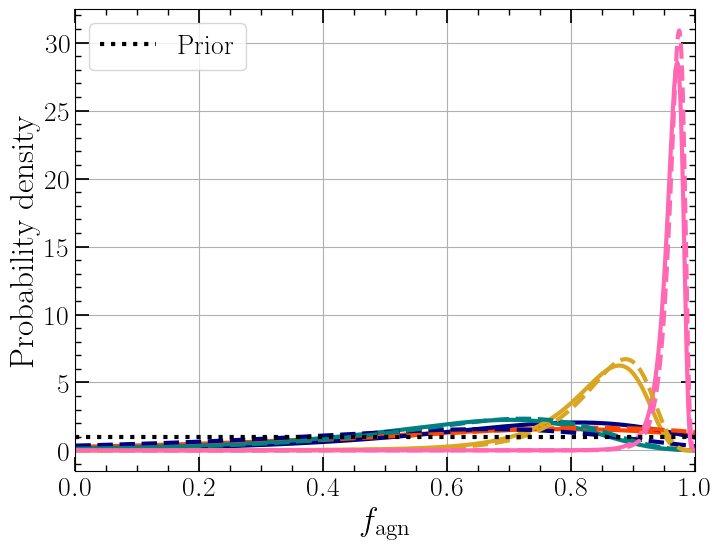

In [8]:
# z_threshold = {'O1': 0.2, 'O2': 0.3, 'O3': 0.5, 'O4': 0.5}

agn_efficiencies = {'O1': np.array([0.000424967, 0.000283632, 0.000150164, 4.203135e-05, 1.200364e-05]),
                    'O2': np.array([0.00149985, 0.00115385531, 0.0005976836, 0.000175245458, 4.41940e-05]),
                    'O3': np.array([0.00826294271, 0.0068422, 0.004294595, 0.001604725, 0.000407629057]),
                    'O4': np.array([0.00826294271, 0.0068422, 0.004294595, 0.001604725, 0.000407629057])
                }
alt_efficiencies = {'O1': np.array([0.00091622, 0.000923194, 0.000911001, 0.00095129033, 0.0008917289]).mean(),
                    'O2': np.array([0.003016407, 0.00304580991, 0.0030851, 0.00309078037, 0.0030418]).mean(),
                    'O3': np.array([0.0139971, 0.01384343, 0.0136893523, 0.0136818, 0.013602378]).mean(),
                    'O4': np.array([0.0139971, 0.01384343, 0.0136893523, 0.0136818, 0.013602378]).mean()
                }

def n_log_alpha(n, agn_efficiency, alt_efficiency):
    return n * np.log10(agn_efficiency * LOG_LLH_X_AX + (1 - LOG_LLH_X_AX) * alt_efficiency)


fig, ax = plt.subplots(figsize=(8,6))

for k, json_path in enumerate(['/home/lucas/Documents/PhD/gw_data/real_output.json', '/home/lucas/Documents/PhD/gw_data/real_output_nocat.json']):

    if k == 1:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'

    with open(json_path, "r") as f:
        data = json.load(f)

    for i, thresh in enumerate(['44.5_kulkarni', '45.0_kulkarni', '45.5_kulkarni', '46.0_kulkarni', '46.5_kulkarni']):
        print(thresh)

        gw_evidence_dict = data[str(thresh)]

        log_llh = 0
        nO1 = 0
        nO2 = 0
        nO3 = 0
        nO4 = 0
        for gwkey in gw_evidence_dict.keys():

            run = get_run(gwkey)
            # if run != 'O3':
            #     continue

            # if mass_dict[gwkey][0] > 40:
            #     continue

            if run == 'O1':
                nO1 += 1
            elif run == 'O2':
                nO2 += 1
            elif run == 'O3':
                nO3 += 1
            elif run == 'O4':
                nO4 += 1

            # if redshift_dict[gwkey][0] > z_threshold[get_run(gwkey)]:
            #     continue
            
            S_agn_incat = gw_evidence_dict[gwkey]['S_agn_incat']
            S_agn_outofcat = gw_evidence_dict[gwkey]['S_agn_outcat']
            S_alt = gw_evidence_dict[gwkey]['S_alt']

            log_llh += np.log10(LOG_LLH_X_AX * (S_agn_incat + S_agn_outofcat - S_alt) + S_alt)
        
        print(nO1, nO2, nO3, nO4, nO1 + nO2 + nO3 + nO4)
        total_alpha = n_log_alpha(nO1, agn_efficiencies['O1'][i], alt_efficiencies['O1']) \
                        + n_log_alpha(nO2, agn_efficiencies['O2'][i], alt_efficiencies['O2']) \
                        + n_log_alpha(nO3, agn_efficiencies['O3'][i], alt_efficiencies['O3']) \
                        + n_log_alpha(nO4, agn_efficiencies['O4'][i], alt_efficiencies['O4'])
                    
        log_llh -= total_alpha

        pdfs = get_pdfs(log_llh, LOG_LLH_X_AX)
        ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[i], linewidth=3, linestyle=linestyle)

ax.hlines(1, 0, 1, linestyles='dotted', colors='black', label='Prior', linewidth=3)
ax.grid()
ax.legend()
ax.set_xlabel(r'$f_{\rm agn}$')
ax.set_ylabel('Probability density')
ax.set_xlim(0, 1)
# ax.semilogy()
# plt.savefig('p26plots/44p5_preliminary_posterior.pdf', bbox_inches='tight')
plt.show()


In [9]:
# agn_efficiencies = np.array([0.00149985, 0.00115385531, 0.0005976836, 0.000175245458, 4.41940e-05])
# alt_efficiency = np.array([0.003016407, 0.00304580991, 0.0030851, 0.00309078037, 0.0030418]).mean()
# Ngw = 167

# json_path = '/home/lucas/Documents/PhD/realdata.json'
# with open(json_path, "r") as f:
#     runs = json.load(f)

# fig, ax = plt.subplots(figsize=(8,6))
# start, stop = 0, 10

# for i, thresh in enumerate([44.5, 45.0, 45.5, 46.0, 46.5]):
#     print(thresh)

#     latest_run_with_thresh = [r for r in runs if r['config']['LUM_THRESH'] == str(thresh)][-1]

#     posterior_path = latest_run_with_thresh['filename']
#     data = np.load(posterior_path)
#     posterior = data['log_likelihood'].flatten()

#     agn_efficiency = agn_efficiencies[i]
#     posterior -= Ngw * np.log(agn_efficiency * LOG_LLH_X_AX + (1 - LOG_LLH_X_AX) * alt_efficiency)

#     print('Starting with log-llh of shape:', posterior.shape)
#     posterior = posterior[:, np.isfinite(posterior).all(axis=0)]
#     print('After removing infs:', posteriors_shape)
#     posterior = posterior[:, start:stop]
#     print('After applying provided start:stop:', posteriors_shape)
#     posteriors_shape = posterior.shape

#     pdfs = get_pdfs(posterior, LOG_LLH_X_AX)
#     print('Plotting PDFs with shape:', pdfs.shape)

#     ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[i], linewidth=3)

# # ax.set_ylim(0, 120)
# ax.set_xlabel(r'$f_{\rm agn}$')
# ax.set_ylabel('Probability density')
# ax.set_xlim(0, 1)
# plt.show()


# Mock data

# Step 1: Completeness = 1, AGN z-error = 0

Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 100)


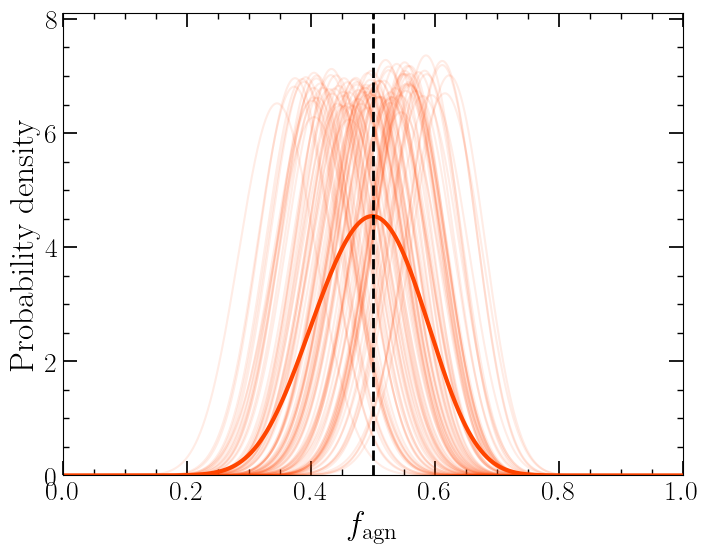

Median 90% CI size = 0.19079992013856323
Median 1 sigma = 0.057947056136677194
Mean 1 sigma = 0.05808924584334626



/tmp/ipykernel_72464/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


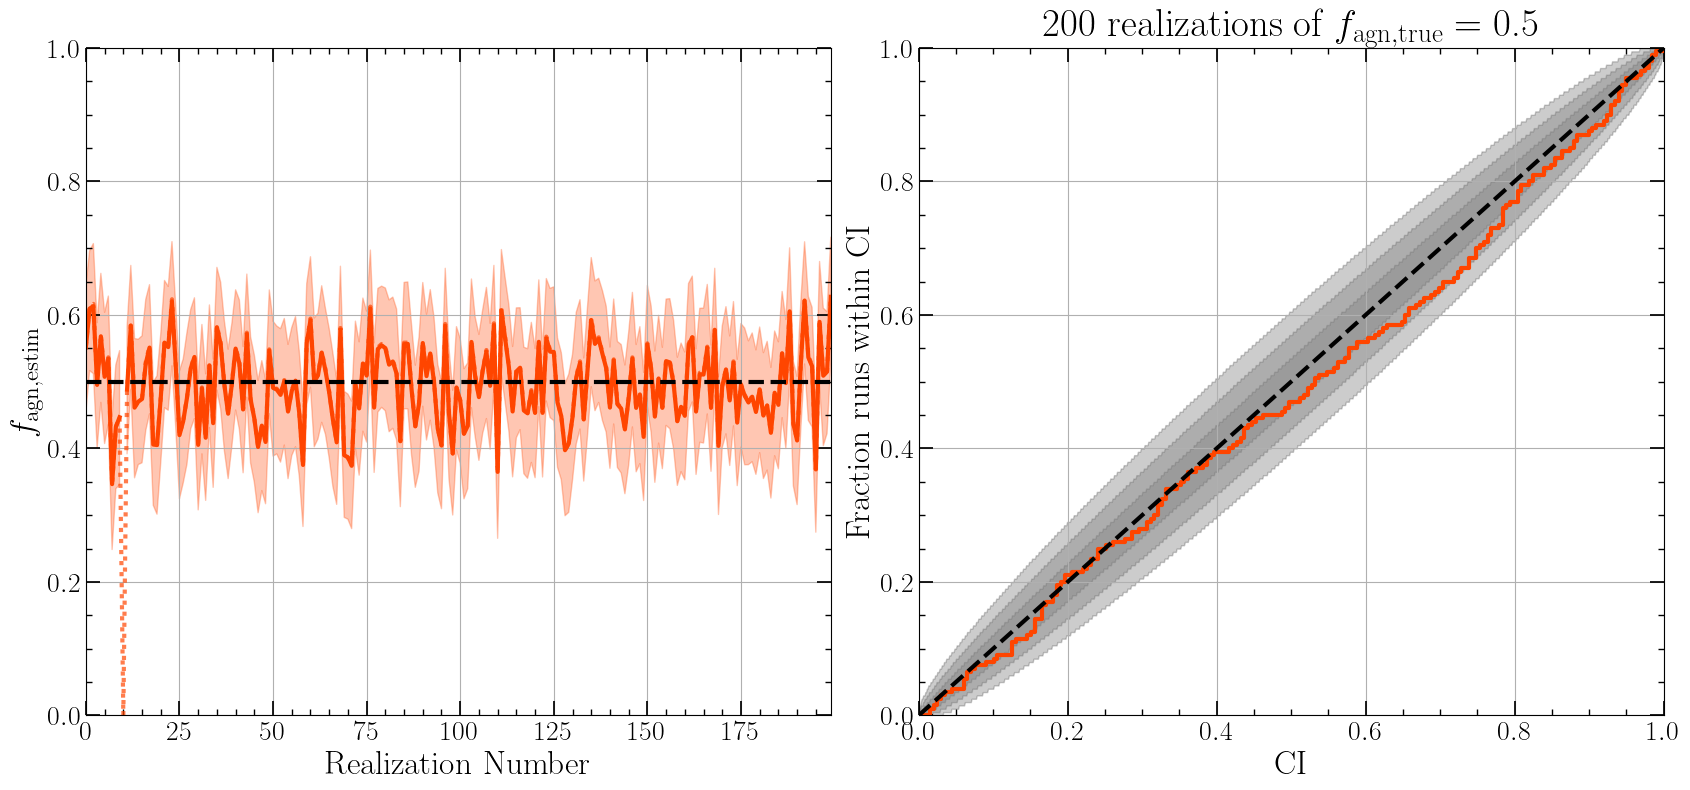

In [10]:
posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_perfz_True_GPmask_False_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_False_gwZmax_1.5_agnZcut_10.npy'
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-04-10T18:31:03.184227.npy'

start = 0
stop = 100

fig, ax = plt.subplots(figsize=(8,6))
make_posterior_plot(posterior_path, ax, start=start, stop=stop)
# plt.savefig('./p26plots/posterior_perfect_catalog.pdf', bbox_inches='tight')
plt.show()

make_PPplot([posterior_path], start=0, stop=1000)

# Step 2: Completeness =/= 1, AGN z-error = 0
### 2A: Instead, we set the completeness to 1 up to z = [0.5, 1.0, 1.5] + masking out the galactic plane
### 2B: We also include a plot with c=0 for comparison, to see how much information the catalog brings

Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 200)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 196)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 200)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 199)


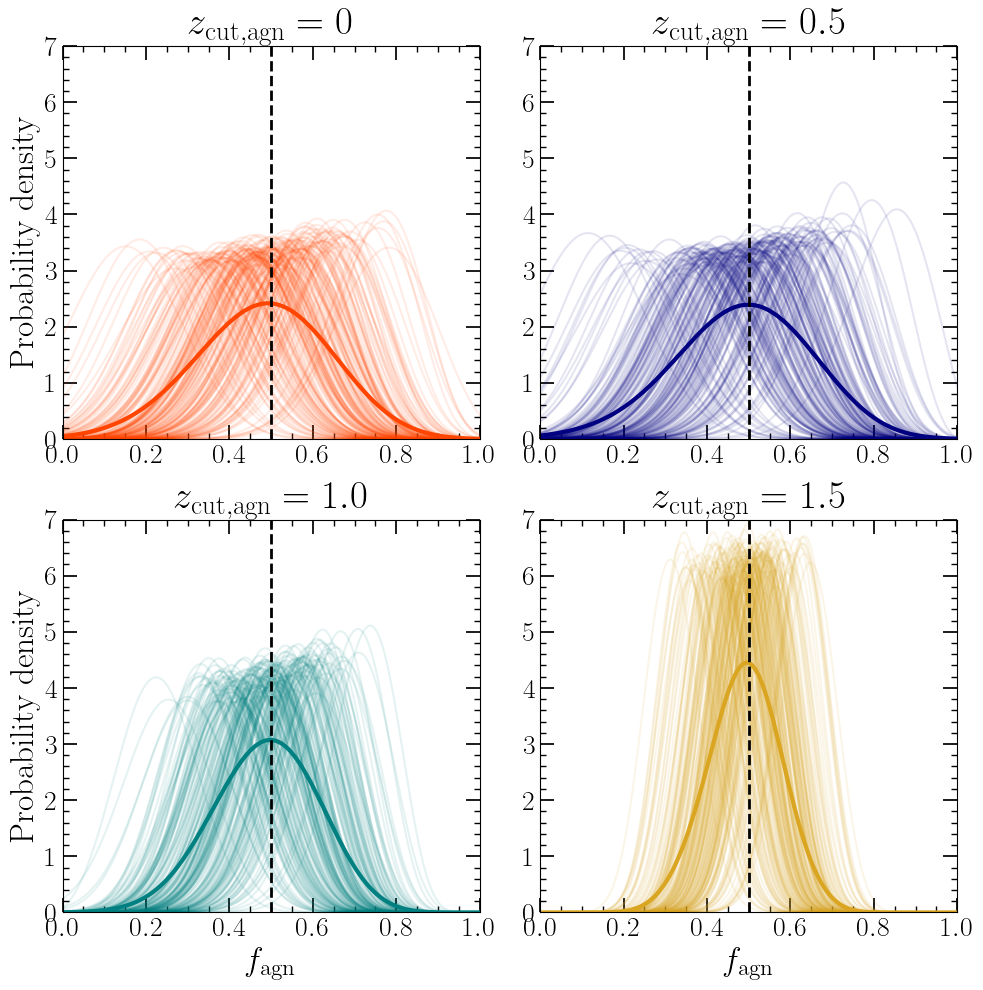

Median 90% CI size = 0.38345682483695964
Median 1 sigma = 0.1168713836373869
Mean 1 sigma = 0.11617656716015944

Median 90% CI size = 0.3784703009266054
Median 1 sigma = 0.11529183185467665
Mean 1 sigma = 0.11491626783402911

Median 90% CI size = 0.3023327840586407
Median 1 sigma = 0.09207299322632943
Mean 1 sigma = 0.09243176926259185

Median 90% CI size = 0.20575164947098257
Median 1 sigma = 0.06249751090024358
Mean 1 sigma = 0.06262193996955198



/tmp/ipykernel_72464/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


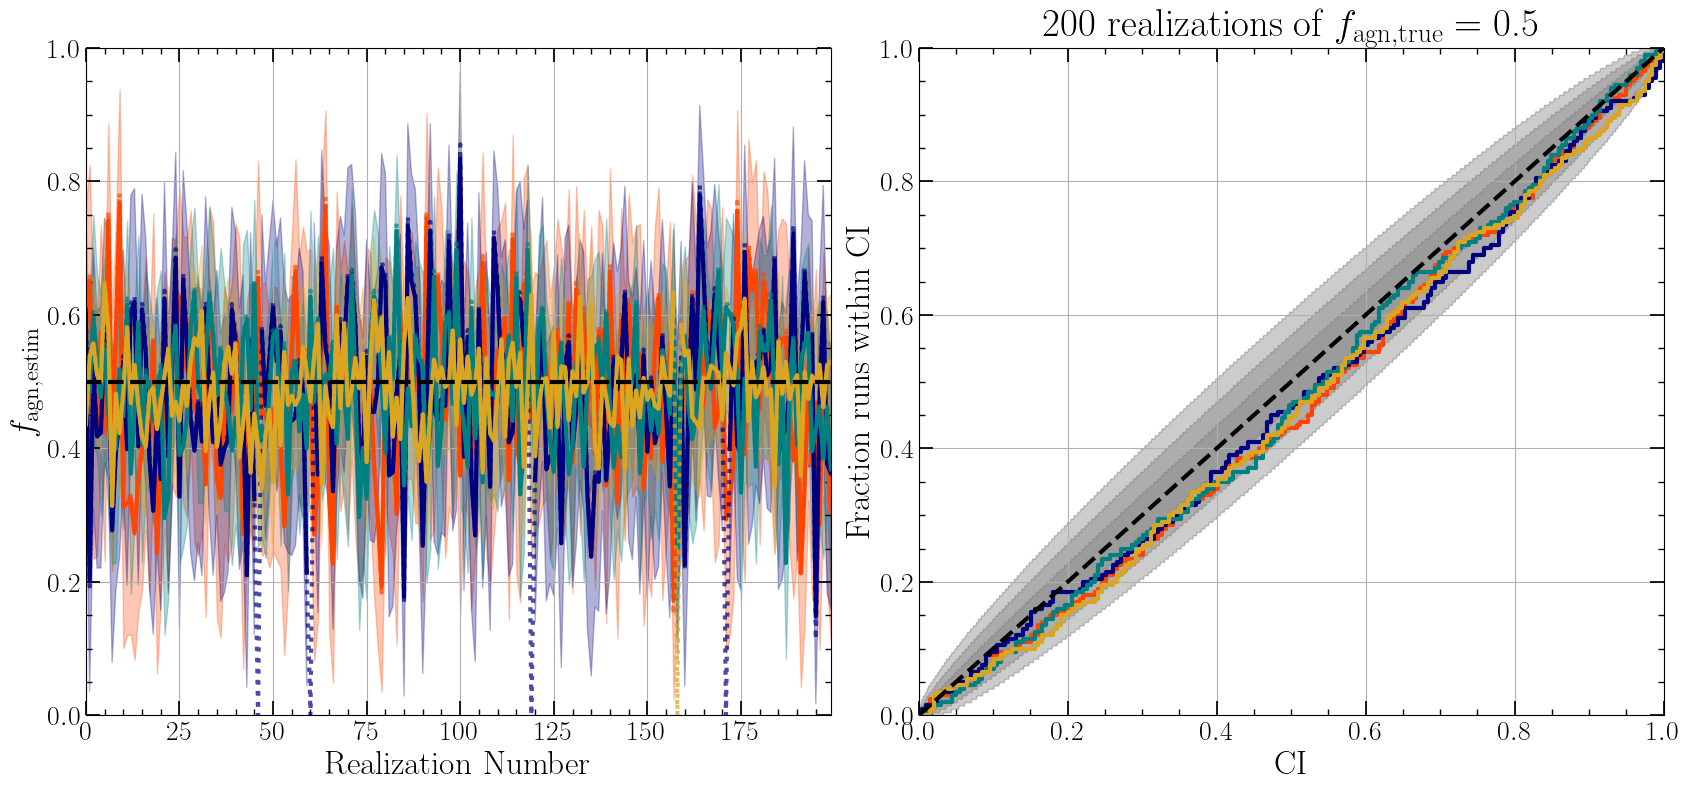

In [11]:
path_zcut0p0 = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_inf_perfz_True_GPmask_False_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_False_gwZmax_1.5_agnZcut_0.npy'
path_zcut0p5 = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_True_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_False_gwZmax_1.5_agnZcut_0.5.npy'
path_zcut1p0 = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_True_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_False_gwZmax_1.5_agnZcut_1.npy'
path_zcut1p5 = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_True_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_False_gwZmax_1.5_agnZcut_1.5.npy'

ymax = 7
start = 0
stop = 200

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
make_posterior_plot(path_zcut0p0, ax1, start=start, stop=stop, color_idx=0,  ymax=ymax, xlabel=False)
make_posterior_plot(path_zcut0p5, ax2, start=start, stop=stop, color_idx=1,  ymax=ymax, xlabel=False, ylabel=False)
make_posterior_plot(path_zcut1p0, ax3, start=start, stop=stop, color_idx=2, ymax=ymax)
make_posterior_plot(path_zcut1p5, ax4, start=start, stop=stop, color_idx=3, ymax=ymax, ylabel=False)
ax1.set_title(r'$z_{\rm cut, agn} = 0$')
ax2.set_title(r'$z_{\rm cut, agn} = 0.5$')
ax3.set_title(r'$z_{\rm cut, agn} = 1.0$')
ax4.set_title(r'$z_{\rm cut, agn} = 1.5$')
plt.tight_layout()
# plt.savefig('./p26plots/posterior_incomplete_catalog_no_zerr.pdf', bbox_inches='tight')
plt.show()

make_PPplot([path_zcut0p0, path_zcut0p5, path_zcut1p0, path_zcut1p5], start=start, stop=stop)


# Step 3: Completeness =/= 1, AGN z-error =/= 0
### The AGN z-error is sampled from Quaia
### We show the correct inference and the effect of neglecting the redshift error
### Set $z_{\rm cut, agn} = 1.0$ to get incomplete catalog
### Note that this bias will be less severe for realistic localization volumes (which are 100x larger than what I'm using now)

Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 100)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 100)


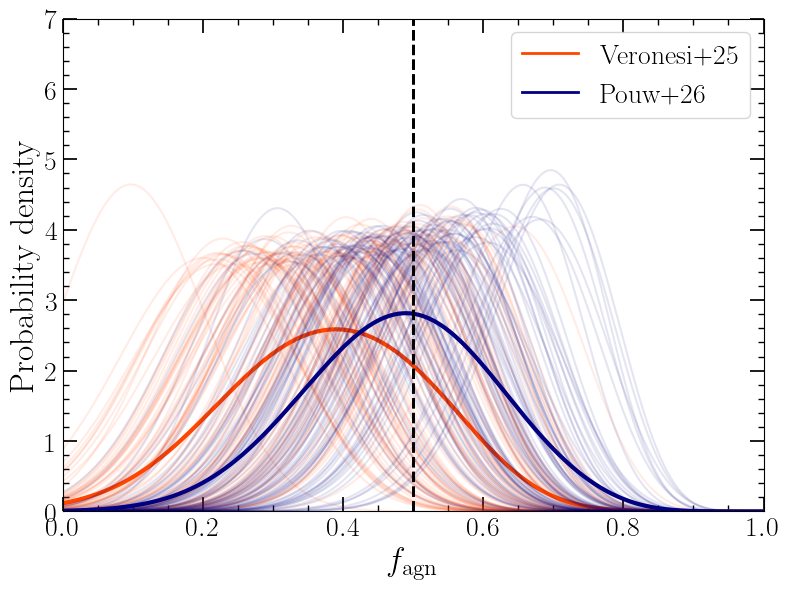

Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 1)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 1)


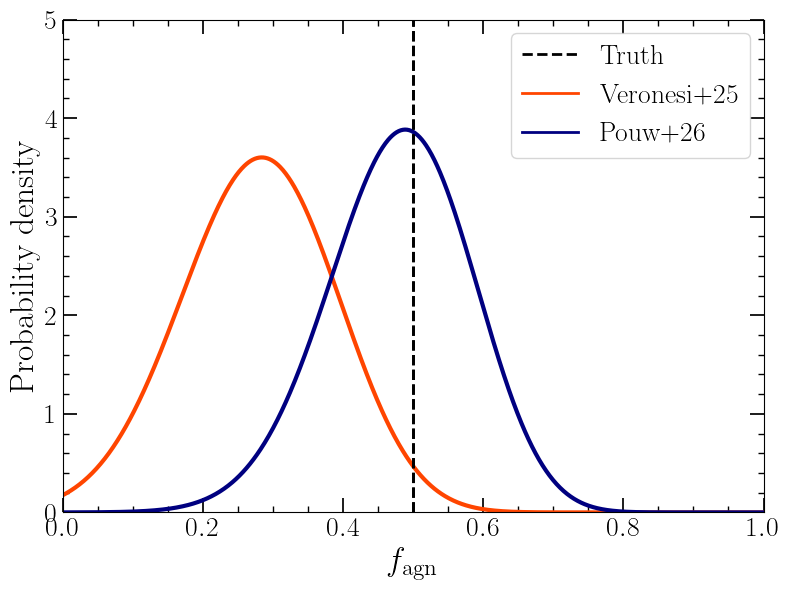

Median 90% CI size = 0.3407978872934263
Median 1 sigma = 0.10396680543317442
Mean 1 sigma = 0.10330509477062584

Median 90% CI size = 0.3314927667231056
Median 1 sigma = 0.10077174211905467
Mean 1 sigma = 0.10019089493170241



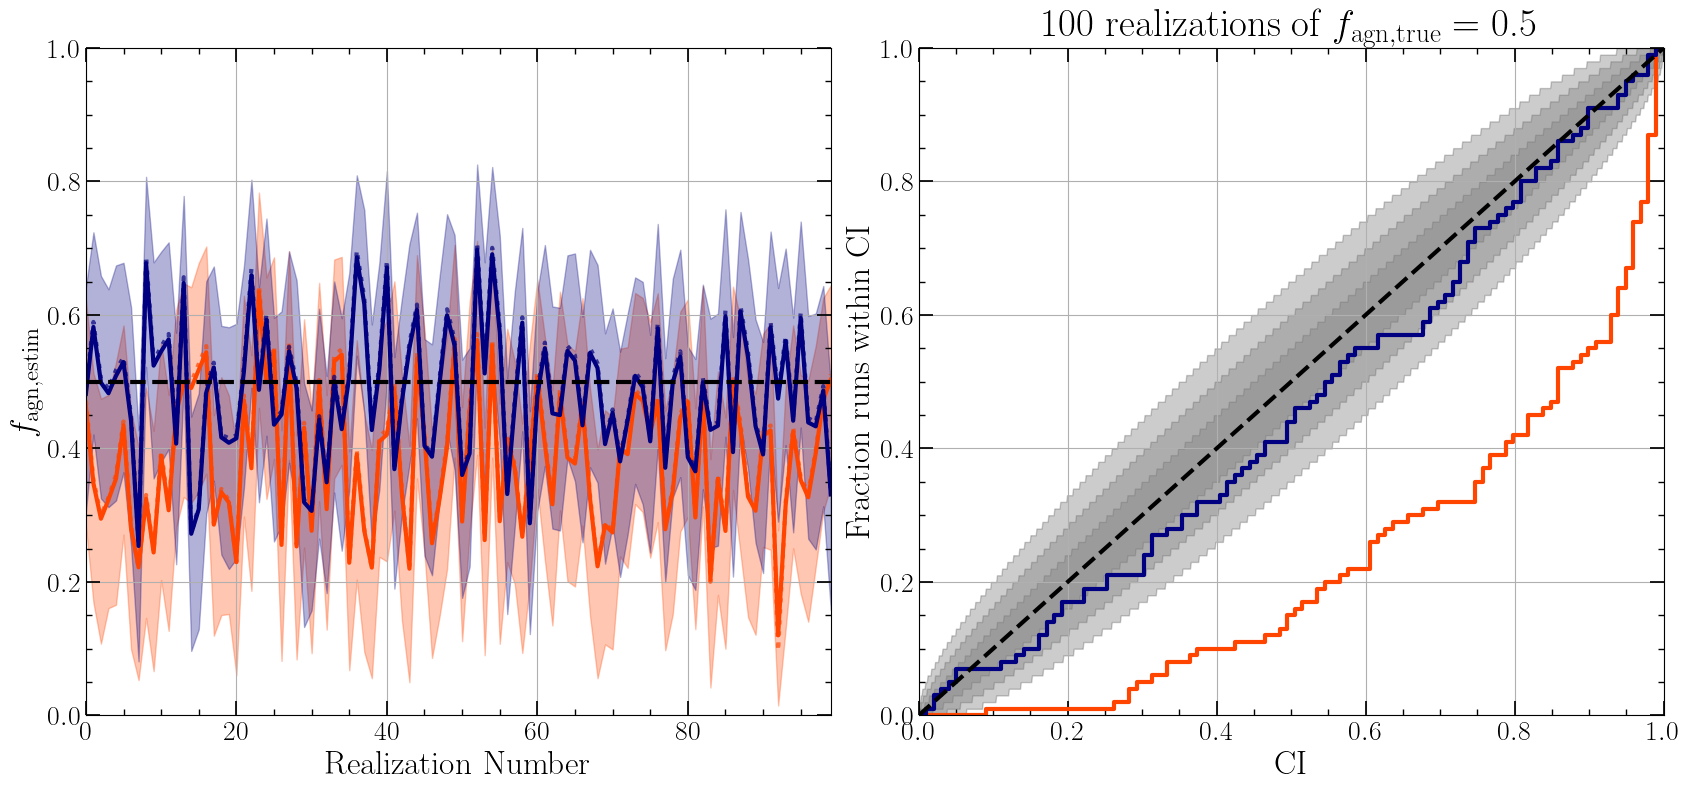

In [12]:
path_v25 = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_True_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_quaia_gwZmax_1.5_agnZcut_1.npy'
path_p26 = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_False_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_quaia_gwZmax_1.5_agnZcut_1.npy'

ymax = 7
start = 0
stop = 100

fig, ax = plt.subplots(figsize=(8, 6))
make_posterior_plot(path_v25, ax, start=start, stop=stop, color_idx=0,  ymax=ymax)
make_posterior_plot(path_p26, ax, start=start, stop=stop, color_idx=1,  ymax=ymax)
custom_lines = [
    Line2D([0], [0], color=COLORS[0], lw=2),
    Line2D([0], [0], color=COLORS[1], lw=2)
]
plt.legend(custom_lines, ['Veronesi+25', 'Pouw+26'])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
make_posterior_plot(path_v25, ax, start=6, stop=7, color_idx=0,  ymax=5)
make_posterior_plot(path_p26, ax, start=0, stop=1, color_idx=1,  ymax=5)
plt.legend(handles=[
    Line2D([], [], color='black', linestyle='dashed', lw=2, label='Truth'),
    Line2D([], [], color=COLORS[0], lw=2, linestyle='solid', label='Veronesi+25'),
    Line2D([], [], color=COLORS[1], lw=2, linestyle='solid', label='Pouw+26')
])
plt.tight_layout()
# plt.savefig('speriplot_2.pdf', bbox_inches='tight')
# plt.savefig('./p26plots/posterior_bias.pdf', bbox_inches='tight')
plt.show()

make_PPplot([path_v25, path_p26], start=start, stop=stop)


# Step 4: Compare Completeness = 0 and completeness =/= 0
### These are the same plots as Step 2, now with AGN z-errors
### Note that the c=0 case is exactly the same as in step 2, since the catalog is empty. We just copy that plot here.

Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 200)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 199)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 200)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 200)


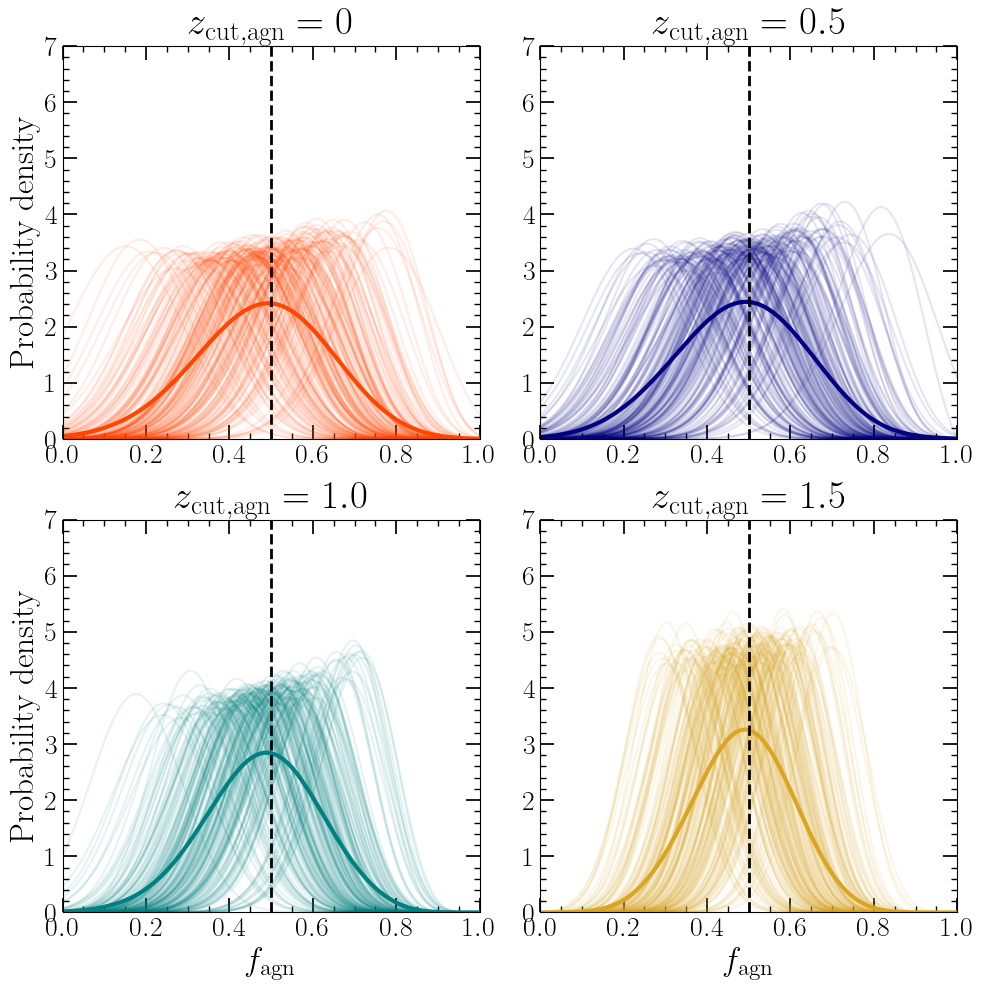

Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 1)
Starting with log-llh of shape: (1000, 200)
After removing infs: (1000, 200)
After applying provided start:stop: (1000, 200)
Plotting PDFs with shape: (1000, 1)


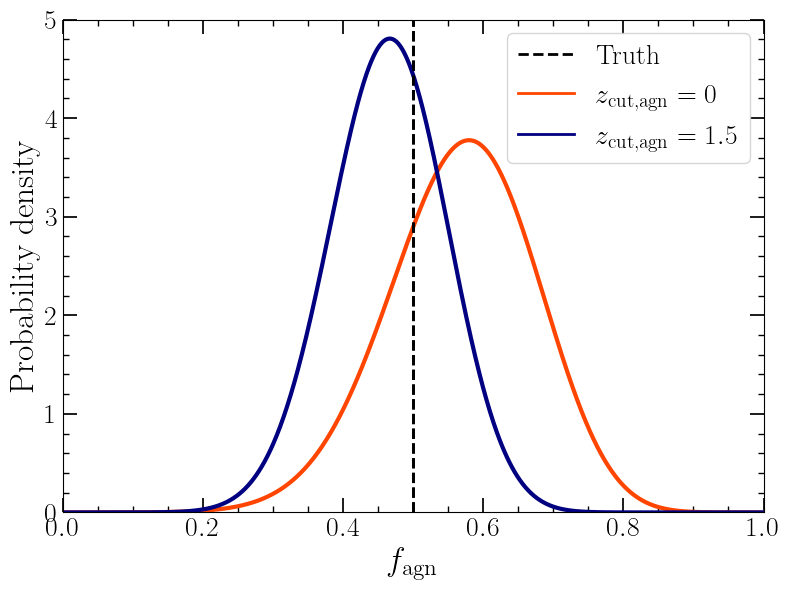

Median 90% CI size = 0.38345682483695964
Median 1 sigma = 0.1168713836373869
Mean 1 sigma = 0.11617656716015944

Median 90% CI size = 0.3779683969447145
Median 1 sigma = 0.11508736960217633
Mean 1 sigma = 0.11448870044443459

Median 90% CI size = 0.3304081754928512
Median 1 sigma = 0.1004692130277729
Mean 1 sigma = 0.10007405061236341

Median 90% CI size = 0.2741640707969194
Median 1 sigma = 0.08337838795793306
Mean 1 sigma = 0.08328555677904147



/tmp/ipykernel_72464/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


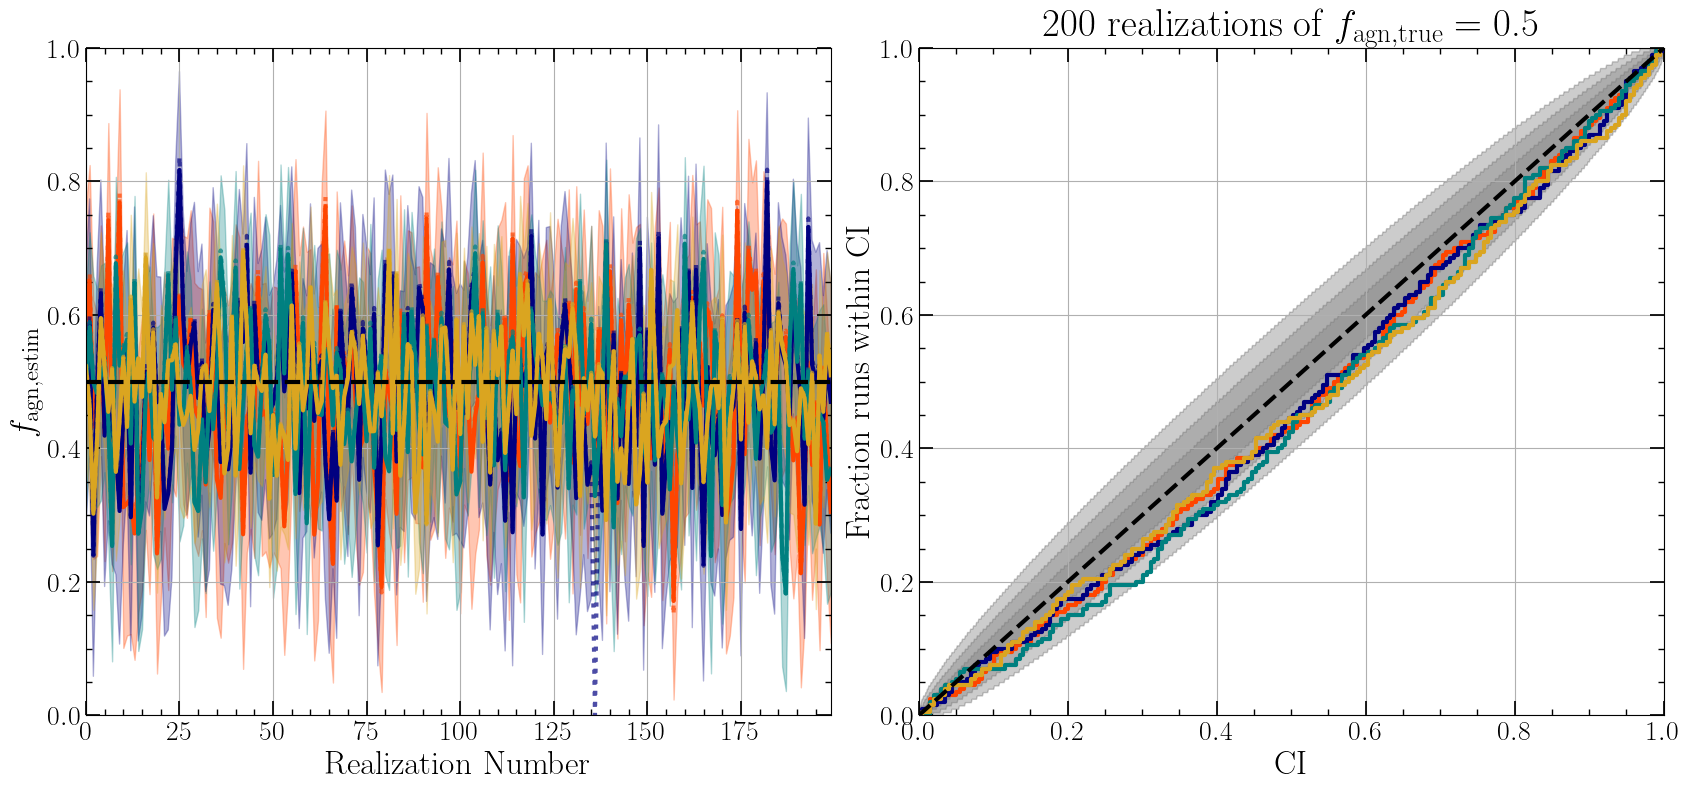

In [13]:
path_zcut0p0 = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_inf_perfz_True_GPmask_False_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_False_gwZmax_1.5_agnZcut_0.npy'
path_zcut0p5_quaiaerr = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_False_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_quaia_gwZmax_1.5_agnZcut_0.5.npy'
path_zcut1p0_quaiaerr = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_False_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_quaia_gwZmax_1.5_agnZcut_1.npy'
path_zcut1p5_quaiaerr = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_useskymap_True_rate_madau_timedil_True_agnZprior_46.5_kulkarni_Lthresh_zero_upto_cut_perfz_False_GPmask_True_addAGN_350000_nreal_200_batch_150_CL_0.999_agnZerr_quaia_gwZmax_1.5_agnZcut_1.5.npy'

ymax = 7
start = 0
stop = 200

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
make_posterior_plot(path_zcut0p0, ax1, start=start, stop=stop, color_idx=0,  ymax=ymax, xlabel=False)
make_posterior_plot(path_zcut0p5_quaiaerr, ax2, start=start, stop=stop, color_idx=1,  ymax=ymax, xlabel=False, ylabel=False)
make_posterior_plot(path_zcut1p0_quaiaerr, ax3, start=start, stop=stop, color_idx=2, ymax=ymax)
make_posterior_plot(path_zcut1p5_quaiaerr, ax4, start=start, stop=stop, color_idx=3, ymax=ymax, ylabel=False)
ax1.set_title(r'$z_{\rm cut, agn} = 0$')
ax2.set_title(r'$z_{\rm cut, agn} = 0.5$')
ax3.set_title(r'$z_{\rm cut, agn} = 1.0$')
ax4.set_title(r'$z_{\rm cut, agn} = 1.5$')
plt.tight_layout()
# plt.savefig('./p26plots/posterior_imperfect_catalog.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
make_posterior_plot(path_zcut0p0, ax, start=4, stop=5, color_idx=0,  ymax=5)
make_posterior_plot(path_zcut1p5_quaiaerr, ax, start=1, stop=2, color_idx=1, ymax=5)
plt.legend(handles=[
    Line2D([], [], color='black', linestyle='dashed', linewidth=2, label='Truth'),
    Line2D([], [], color=COLORS[0], linestyle='solid', linewidth=2, label=r'$z_{\rm cut, agn} = 0$'),
    Line2D([], [], color=COLORS[1], linestyle='solid', linewidth=2, label=r'$z_{\rm cut, agn} = 1.5$')
])
plt.tight_layout()
# plt.savefig('speriplot_1.pdf', bbox_inches='tight')
plt.show()

make_PPplot([path_zcut0p0, path_zcut0p5_quaiaerr, path_zcut1p0_quaiaerr, path_zcut1p5_quaiaerr], start=start, stop=stop)


# Step 5: Discussion plots

### 5A: Completeness vs Ngw (changing the redshift threshold up to which the catalog is complete on the y-axis), colorbar sigma-fagn

/tmp/ipykernel_72464/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


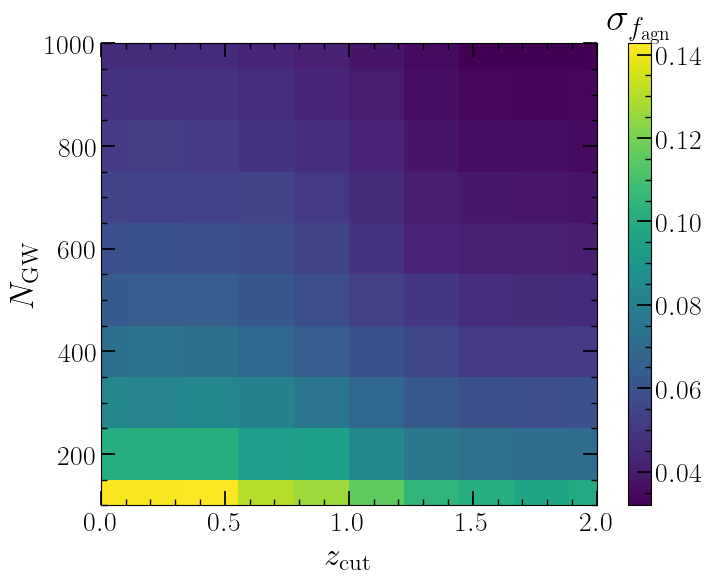

In [14]:
ngws = np.linspace(100, 1000, 10)
agn_zcuts = np.linspace(0, 2, 10)

param_values_dict = {
    "BATCH": ngws,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, _ = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/ngws_vs_zcut.json", param_values_dict)

X, Y = np.meshgrid(agn_zcuts, ngws)

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', rasterized=True)
plt.xlim(agn_zcuts.min(), agn_zcuts.max())
plt.ylim(ngws.min(), ngws.max())
plt.xlabel(r"$z_{\rm cut}$")
plt.ylabel(r"$N_{\rm GW}$")
cbar = plt.colorbar(pcm)
cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
plt.show()


/tmp/ipykernel_72464/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


-0.48599286823911647
-0.4889369632230851
-0.4888941896602009
-0.4880937111612914
-0.48872266060414565
-0.5043115492121892
-0.48657451945609936


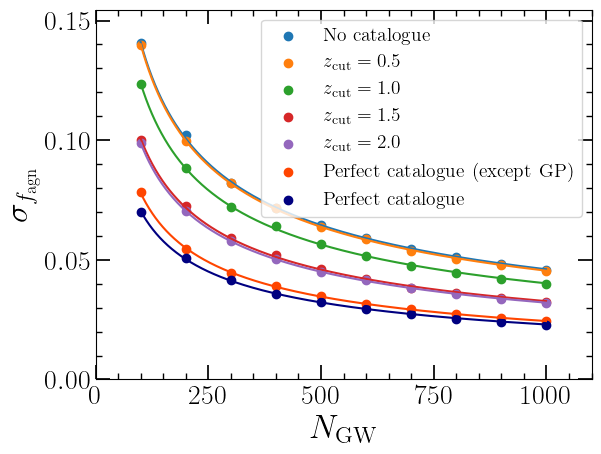

In [15]:
from scipy.optimize import curve_fit

def powerlaw(x, a, b):
    return a * np.power(x, b)


ngws = np.linspace(100, 1000, 10)
agn_zcuts = np.linspace(0, 2, 5)
param_values_dict = {
    "BATCH": ngws,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, _ = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/ngws_vs_zcut2.json", param_values_dict)

param_values_dict = {
    "BATCH": ngws,
    "MASK_GALACTIC_PLANE": [True, False]
}
sig_fagn_perfect, _ = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/ngws_w_perfect_cat.json", param_values_dict)


xax = np.arange(100, 1000, 1)
sqrtN = lambda N: 1 / np.sqrt(N) 

plt.figure()
for k, zcut in enumerate(agn_zcuts):
    if zcut == 0:
        label = 'No catalogue'
    else:
        label = rf'$z_{{\rm cut}} = {zcut:.1f}$'
    plt.scatter(ngws, sig_fagn[:,k], label=label)
    param, pcov = curve_fit(powerlaw, ngws, sig_fagn[:,k])
    plt.plot(xax, powerlaw(xax, *param))
    print(param[1])

for l, mask_GP in enumerate([True, False]):
    if not mask_GP:
        label = 'Perfect catalogue'
    else:
        label = 'Perfect catalogue (except GP)'
    plt.scatter(ngws, sig_fagn_perfect[:,l], label=label, color=COLORS[l])
    param, pcov = curve_fit(powerlaw, ngws, sig_fagn_perfect[:,l])
    plt.plot(xax, powerlaw(xax, *param), color=COLORS[l])
    print(param[1])

plt.legend(fontsize=14)
plt.xlabel(r'$N_{\rm GW}$')
plt.ylabel(r"$\sigma_{f_{\rm agn}}$")
plt.xlim(0, 1100)
plt.ylim(0, np.max(sig_fagn) * 1.1)
# plt.title('GWs up to z=1.5, all observed')
# plt.savefig('./p26plots/constraint_ngw_catalogue_quality.pdf', bbox_inches='tight')
plt.show()



/tmp/ipykernel_72464/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


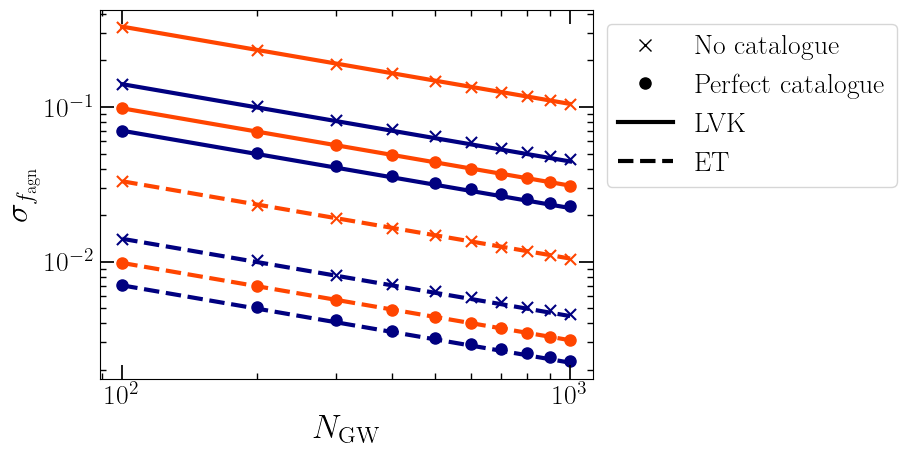

In [16]:
ngws = np.linspace(100, 1000, 10)
agn_zcuts = [0]
param_values_dict = {
    "BATCH": ngws,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, _ = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/ngws_vs_zcut2.json", param_values_dict)

param_values_dict = {
    "BATCH": ngws,
    "MASK_GALACTIC_PLANE": [False]
}
sig_fagn_perfect, _ = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/ngws_w_perfect_cat.json", param_values_dict)


MSIZE = 8**2
LWIDTH = 3
xax = np.arange(100, 1000, 1)
sqrtN = lambda N: 1 / np.sqrt(N) 


fig, ax = plt.subplots()
for k, zcut in enumerate(agn_zcuts):
    if zcut == 0:
        label = 'No catalogue'
    else:
        label = rf'$z_{{\rm cut}} = {zcut:.1f}$'
    ax.scatter(ngws, sig_fagn[:,k], label=label, color=COLORS[1], marker='x', s=MSIZE)
    ax.plot(xax, sig_fagn[0,k] * sqrtN(xax / ngws[0]), color=COLORS[1], linewidth=LWIDTH)

for l, mask_GP in enumerate([False]):
    if not mask_GP:
        label = 'Perfect catalogue'
    else:
        label = 'Perfect catalogue (except GP)'
    ax.scatter(ngws, sig_fagn_perfect[:,l], label=label, color=COLORS[1], marker='o', s=MSIZE)
    ax.plot(xax, sig_fagn_perfect[0,l] * sqrtN(xax / ngws[0]), color=COLORS[1], linewidth=LWIDTH)

ax.scatter(ngws, 0.27 / np.sqrt(ngws / 150), color=COLORS[0], marker='x', s=MSIZE)
ax.plot(xax, 0.27 / np.sqrt(xax / 150), color=COLORS[0], linewidth=LWIDTH)
ax.scatter(ngws, 0.08 / np.sqrt(ngws / 150), color=COLORS[0], marker='o', s=MSIZE)
ax.plot(xax, 0.08 / np.sqrt(xax / 150), color=COLORS[0], linewidth=LWIDTH)


F = 10

for k, zcut in enumerate(agn_zcuts):
    if zcut == 0:
        label = 'No catalogue'
    else:
        label = rf'$z_{{\rm cut}} = {zcut:.1f}$'
    ax.scatter(ngws, sig_fagn[:,k] / F, label=label, color=COLORS[1], marker='x', s=MSIZE)
    ax.plot(xax, sig_fagn[0,k] / F * sqrtN(xax / ngws[0]), color=COLORS[1], linestyle='dashed', linewidth=LWIDTH)

for l, mask_GP in enumerate([False]):
    if not mask_GP:
        label = 'Perfect catalogue'
    else:
        label = 'Perfect catalogue (except GP)'
    ax.scatter(ngws, sig_fagn_perfect[:,l] / F, label=label, color=COLORS[1], marker='o', s=MSIZE)
    ax.plot(xax, sig_fagn_perfect[0,l] / F * sqrtN(xax / ngws[0]), color=COLORS[1], linestyle='dashed', linewidth=LWIDTH)

ax.scatter(ngws, 0.27 / np.sqrt(ngws / 150) / F, color=COLORS[0], marker='x', s=MSIZE)
ax.plot(xax, 0.27 / np.sqrt(xax / 150) / F, color=COLORS[0], linestyle='dashed', linewidth=LWIDTH)
ax.scatter(ngws, 0.08 / np.sqrt(ngws / 150) / F, color=COLORS[0], marker='o', s=MSIZE)
ax.plot(xax, 0.08 / np.sqrt(xax / 150) / F, color=COLORS[0], linestyle='dashed', linewidth=LWIDTH)




ax.legend(handles=[
    Line2D([], [], color='black', linestyle='', marker='x', label='No catalogue', markersize=np.sqrt(MSIZE)),
    Line2D([], [], color='black', linestyle='', marker='o', label='Perfect catalogue', markersize=np.sqrt(MSIZE)),
    Line2D([], [], color='black', linestyle='solid', linewidth=LWIDTH, label=r'LVK'),
    Line2D([], [], color='black', linestyle='dashed', linewidth=LWIDTH, label=r'ET')],
    loc='upper left', bbox_to_anchor=(1, 1))

# plt.legend(handles=[
#     Line2D([], [], color='black', linestyle='', marker='x', label='No catalogue'),
#     Line2D([], [], color='black', linestyle='', marker='o', label='Perfect catalogue'),
#     Line2D([], [], color=COLORS[1], linestyle='solid', linewidth=2, label=r'$L_{\rm bol} \geq 10^{46.5} \, \mathrm{erg \, s^{-1}}$'),
#     Line2D([], [], color=COLORS[0], linestyle='solid', linewidth=2, label=r'$L_{\rm bol} \geq 10^{44.5} \, \mathrm{erg \, s^{-1}}$')
# ])

ax.set_xlabel(r'$N_{\rm GW}$')
ax.set_ylabel(r"$\sigma_{f_{\rm agn}}$")
ax.loglog()
ax.set_box_aspect(6/8)
# plt.savefig('./p26plots/constraint_ngw_catalogue_quality.pdf', bbox_inches='tight')
plt.show()



### 5B: sigma-z-AGN versus V90, colorbar sigma-fagn

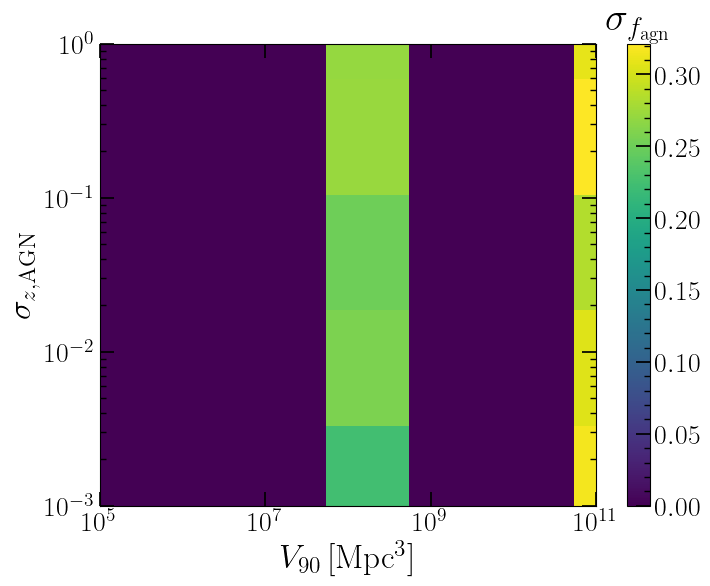

In [17]:
with open("/home/lucas/Documents/PhD/zerr_vs_v90.json", "r") as f:
    runs = json.load(f)

agn_zerrs = np.geomspace(0.001, 1, 5)
ids = np.array(['gws_1e5', 'gws_1e6', 'gws_1e7', 'gws_1e8', 'gws_1e9', 'gws_1e10', 'gws_1e11'])
v90s = np.array([1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11])
sig_fagn = np.zeros((len(agn_zerrs), len(v90s)))

for i, agn_err in enumerate(agn_zerrs):
    for j, (v90, id) in enumerate(zip(v90s, ids)):
        matching_runs = [
                            run for run in runs
                            if run["config"]["AGN_ZERROR"] == agn_err and run["config"]["DIRECTORY_ID"] == id
                        ]

        try:
            run = matching_runs[-1]  # Grab most recent run with same parameters
            sig_fagn[i, j] = get_mean_sigma(run)
        except IndexError:
            sig_fagn[i, j] = 0
        

X, Y = np.meshgrid(v90s, agn_zerrs)

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, sig_fagn[::-1, :], shading='auto', cmap='viridis', rasterized=True)
plt.xlim(v90s.min(), v90s.max())
plt.ylim(agn_zerrs.min(), agn_zerrs.max())

plt.loglog()

plt.xlabel(r"$V_{90} \, \mathrm{[Mpc^{3}]}$")
plt.ylabel(r"$\sigma_{z, \rm AGN}$")
cbar = plt.colorbar(pcm)
cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
plt.show()


### 5C: Completeness vs sigma-z-AGN, colorbar sigma-fagn
#### Todo: use new mock data and sig_z_agn up to 1. Different ways of doing completeness? Different AGN z distributions?


### The unbiased case

0.00011499237117597448


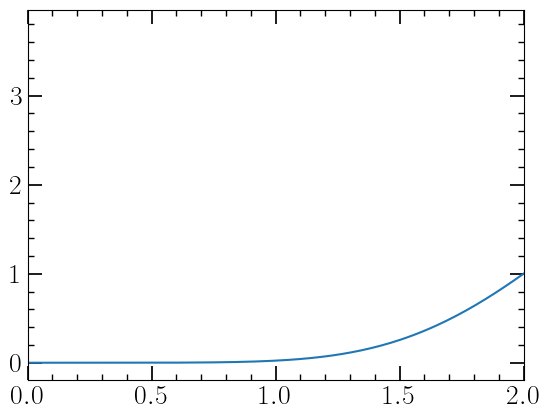

0.0036816049762786237


In [18]:
from scipy.integrate import cumulative_trapezoid

z, agnpdf = np.load('/home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_46.5_kulkarni.npy')
agncdf = cumulative_trapezoid(agnpdf, z)
# plt.plot(z, agnpdf)
# plt.plot(z[:-1], agncdf)
# plt.show()

agncdf_46p5_interp = interp1d(z[:-1], agncdf, bounds_error=False, fill_value=0)
print(agncdf_46p5_interp(0.5))

agncdf_46p5_interp = interp1d(z[:-1], agncdf_46p5_interp(z[:-1]) / agncdf_46p5_interp(2), bounds_error=False, fill_value=0)
plt.figure()
plt.plot(z[:-1], agncdf_46p5_interp(z[:-1]))
plt.xlim(0, 2)
plt.show()

z, agnpdf = np.load('/home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_44.5_kulkarni.npy')
agncdf = cumulative_trapezoid(agnpdf, z)
# plt.plot(z, agnpdf)
# plt.plot(z[:-1], agncdf)
# plt.show()

agncdf_44p5_interp = interp1d(z[:-1], agncdf, bounds_error=False, fill_value=0)
print(agncdf_44p5_interp(0.5))

agncdf_44p5_interp = interp1d(z[:-1], agncdf / agncdf_44p5_interp(0.2), bounds_error=False, fill_value=0) 


/tmp/ipykernel_72464/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


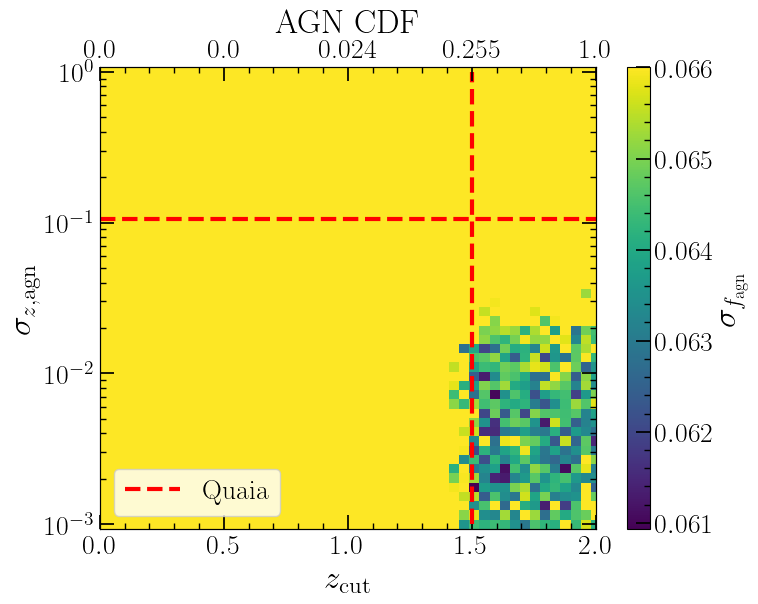

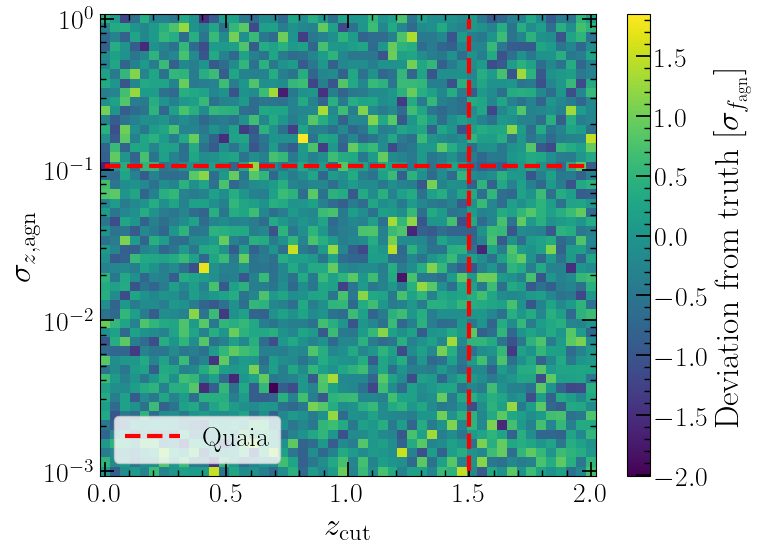

In [28]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/agn_zcut_vs_zerr2.json", param_values_dict)

X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

fig, ax = plt.subplots(figsize=(8,6))  #plt.figure(figsize=(8,6))
pcm = ax.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', rasterized=True, vmax=0.066)  # , vmin=0.058, vmax=0.116
ax.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
ax.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
ax.set_xlabel(r"$z_{\rm cut}$")
ax.set_ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"$\sigma_{f_{\rm agn}}$")
# cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
ax.set_yscale('log')
ax.legend(loc='lower left')
upperax = ax.twiny()
cdfticks = np.array([0, 0.5, 1, 1.5, 2])
upperax.set_xticks(cdfticks)
upperax.set_xticklabels(np.around(agncdf_46p5_interp(cdfticks), 3))
upperax.set_xlabel('AGN CDF')
ax.set_xlim(X.min(), X.max())
upperax.set_xlim(X.min(), X.max())
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.yscale('log')
plt.legend(loc='lower left')
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()


/tmp/ipykernel_74397/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


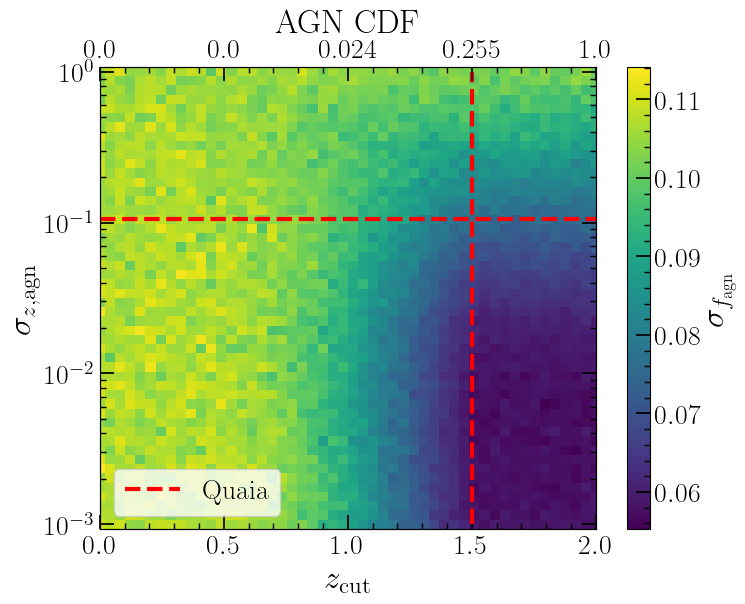

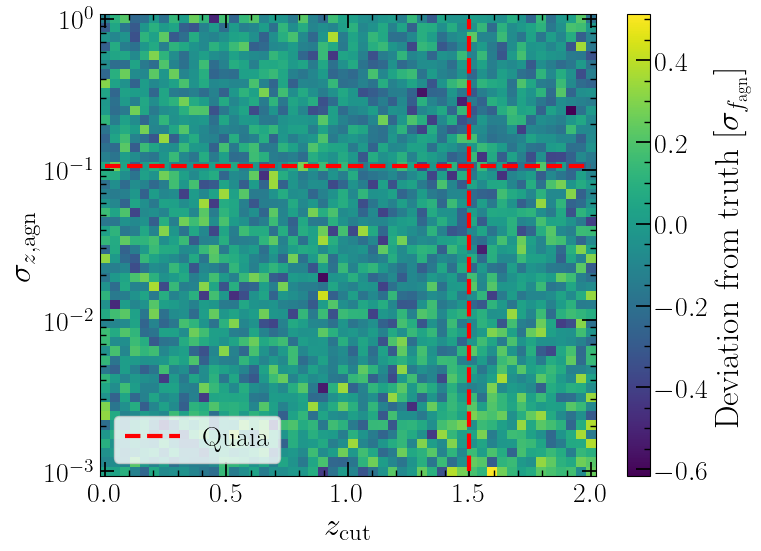

In [20]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/agn_zcut_vs_zerr_fagn02.json", param_values_dict)

X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

fig, ax = plt.subplots(figsize=(8,6))  #plt.figure(figsize=(8,6))
pcm = ax.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', rasterized=True)  # , vmin=0.058, vmax=0.116
ax.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
ax.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
ax.set_xlabel(r"$z_{\rm cut}$")
ax.set_ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"$\sigma_{f_{\rm agn}}$")
# cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
ax.set_yscale('log')
ax.legend(loc='lower left')
upperax = ax.twiny()
cdfticks = np.array([0, 0.5, 1, 1.5, 2])
upperax.set_xticks(cdfticks)
upperax.set_xticklabels(np.around(agncdf_46p5_interp(cdfticks), 3))
upperax.set_xlabel('AGN CDF')
ax.set_xlim(X.min(), X.max())
upperax.set_xlim(X.min(), X.max())
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.yscale('log')
plt.legend(loc='lower left')
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()


/tmp/ipykernel_74397/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


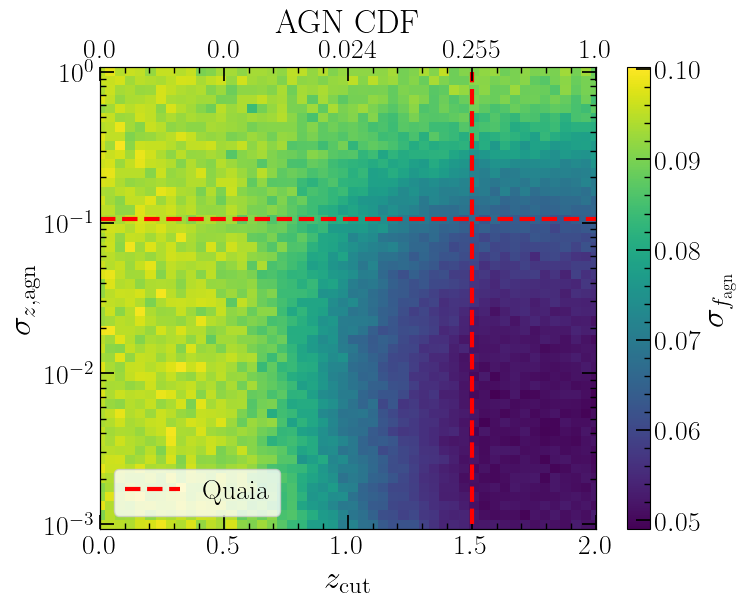

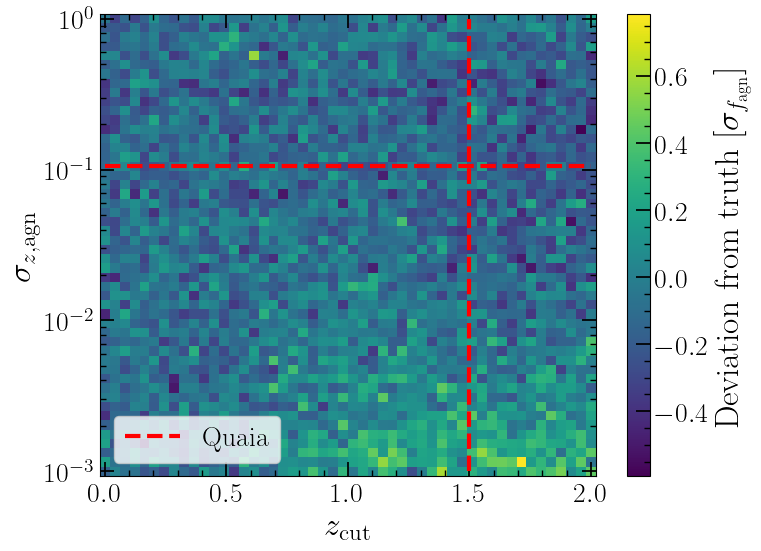

In [21]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/agn_zcut_vs_zerr_fagn08.json", param_values_dict)

X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

fig, ax = plt.subplots(figsize=(8,6))  #plt.figure(figsize=(8,6))
pcm = ax.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', rasterized=True)  # , vmin=0.058, vmax=0.116
ax.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
ax.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
ax.set_xlabel(r"$z_{\rm cut}$")
ax.set_ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"$\sigma_{f_{\rm agn}}$")
# cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
ax.set_yscale('log')
ax.legend(loc='lower left')
upperax = ax.twiny()
cdfticks = np.array([0, 0.5, 1, 1.5, 2])
upperax.set_xticks(cdfticks)
upperax.set_xticklabels(np.around(agncdf_46p5_interp(cdfticks), 3))
upperax.set_xlabel('AGN CDF')
ax.set_xlim(X.min(), X.max())
upperax.set_xlim(X.min(), X.max())
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.yscale('log')
plt.legend(loc='lower left')
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()


### Same, now 44.5

/tmp/ipykernel_74397/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


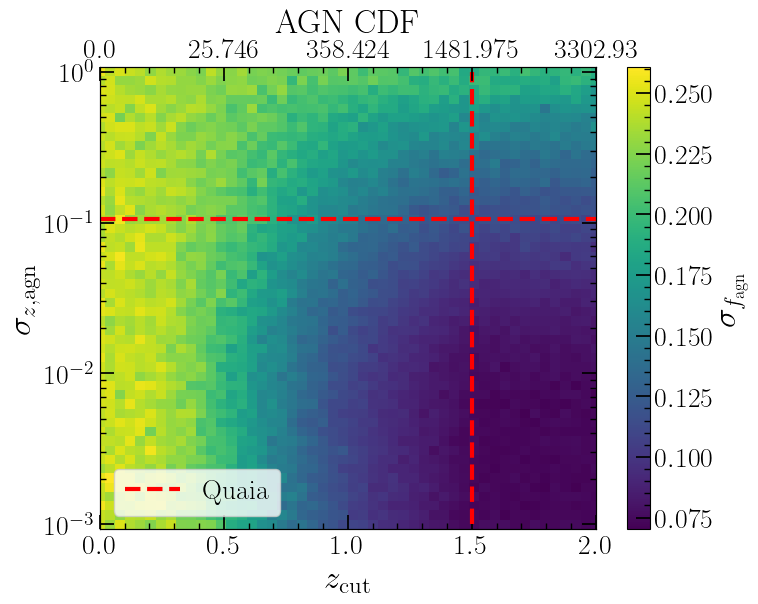

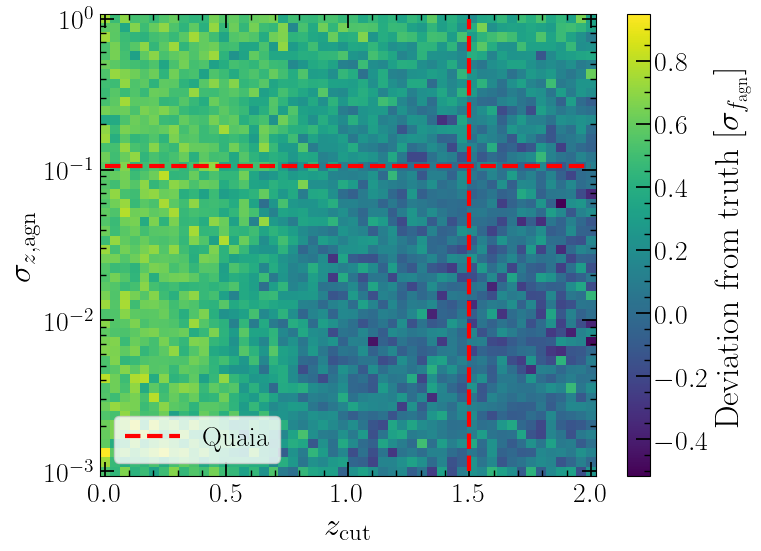

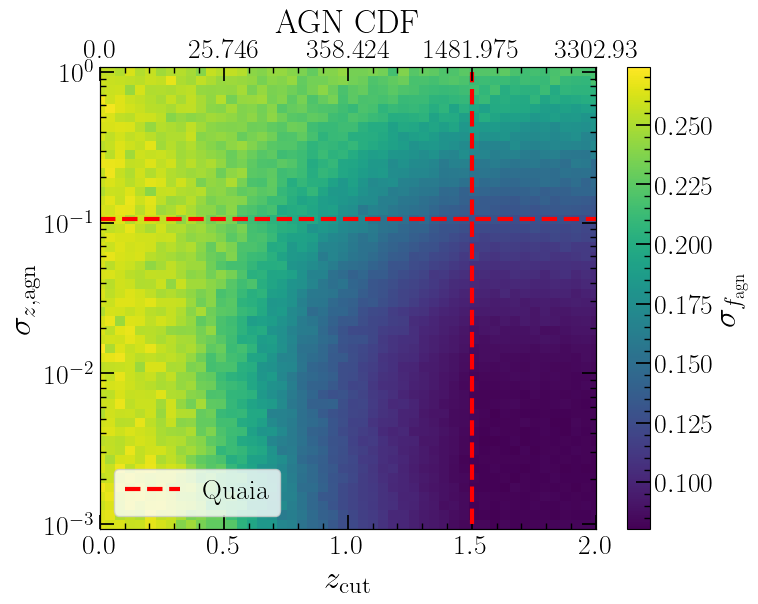

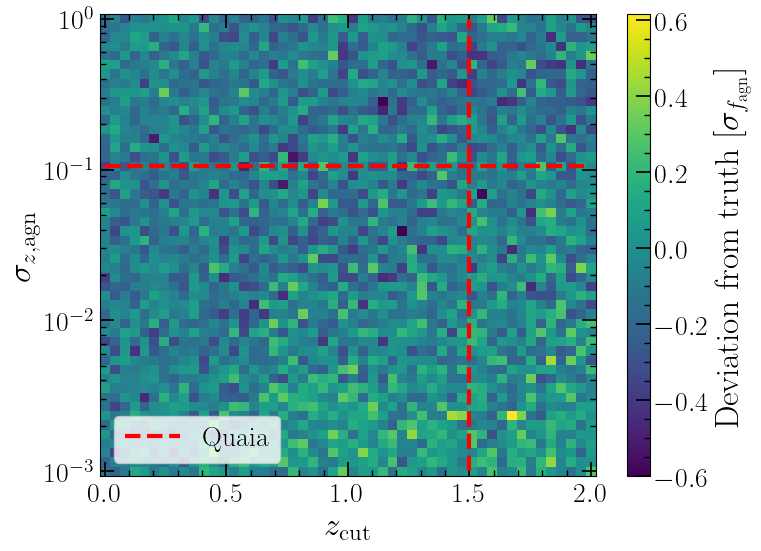

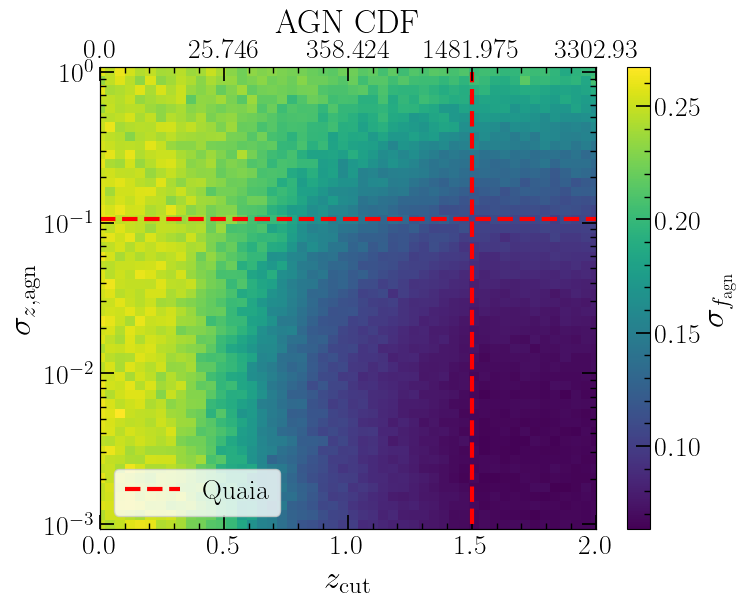

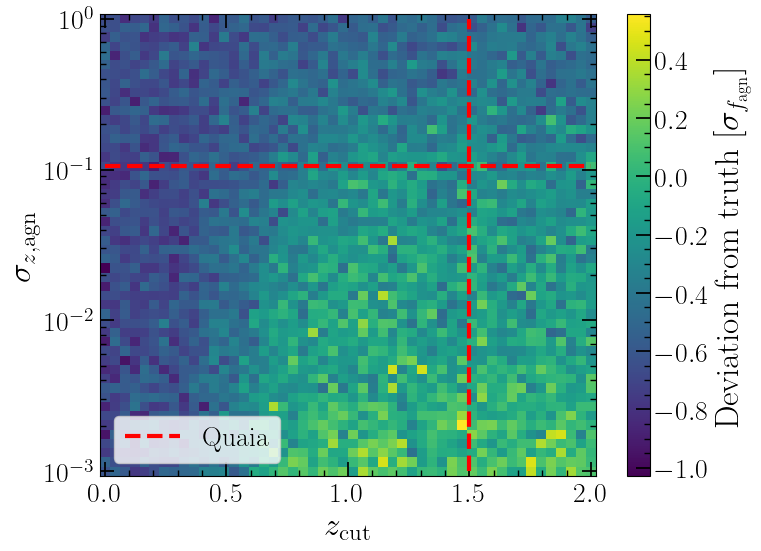

In [22]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)
fagns = np.array([0.2, 0.5, 0.8])

param_values_dict = {
        "AGN_ZERROR": agn_zerrs,
        "AGN_ZCUT": agn_zcuts,
        "TRUE_FAGN": fagns,
    }

sig_fagn_all, mean_deviation_all = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/agn_zcut_vs_zerr_445.json", 
                                                             param_values_dict)

X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

for i, f in enumerate(fagns):
    
    sig_fagn = sig_fagn_all[:,:,i]
    mean_deviation = mean_deviation_all[:,:,i]

    fig, ax = plt.subplots(figsize=(8,6))  #plt.figure(figsize=(8,6))
    pcm = ax.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', rasterized=True)  # , vmin=0.058, vmax=0.116
    ax.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
    ax.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
    ax.set_xlabel(r"$z_{\rm cut}$")
    ax.set_ylabel(r"$\sigma_{z, \rm agn}$")
    cbar = plt.colorbar(pcm, label=r"$\sigma_{f_{\rm agn}}$")
    # cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
    ax.set_yscale('log')
    ax.legend(loc='lower left')
    upperax = ax.twiny()
    cdfticks = np.array([0, 0.5, 1, 1.5, 2])
    upperax.set_xticks(cdfticks)
    upperax.set_xticklabels(np.around(agncdf_44p5_interp(cdfticks), 3))
    upperax.set_xlabel('AGN CDF')
    ax.set_xlim(X.min(), X.max())
    upperax.set_xlim(X.min(), X.max())
    # plt.savefig('./p26plots/constraint_catalog_quality.pdf')
    plt.show()

    plt.figure(figsize=(8,6))
    pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
    plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
    plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
    plt.xlabel(r"$z_{\rm cut}$")
    plt.ylabel(r"$\sigma_{z, \rm agn}$")
    cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
    plt.yscale('log')
    plt.legend(loc='lower left')
    # plt.savefig('./p26plots/constraint_catalog_quality.pdf')
    plt.show()


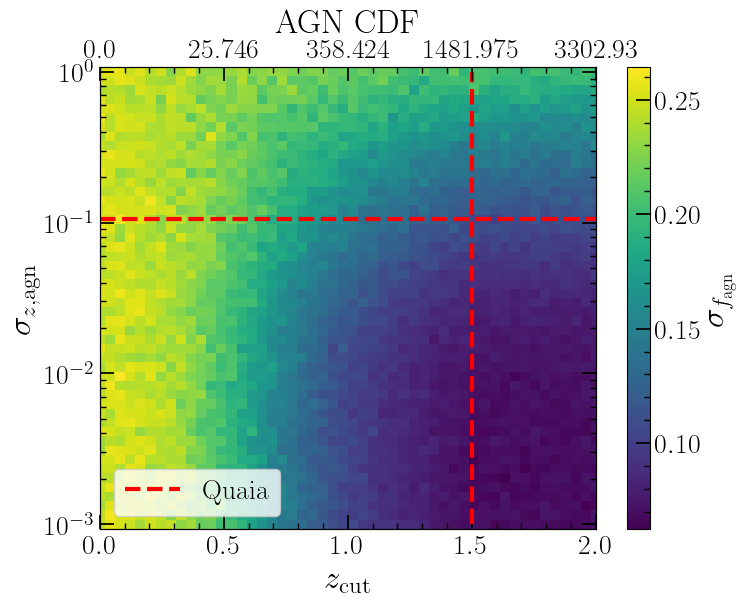

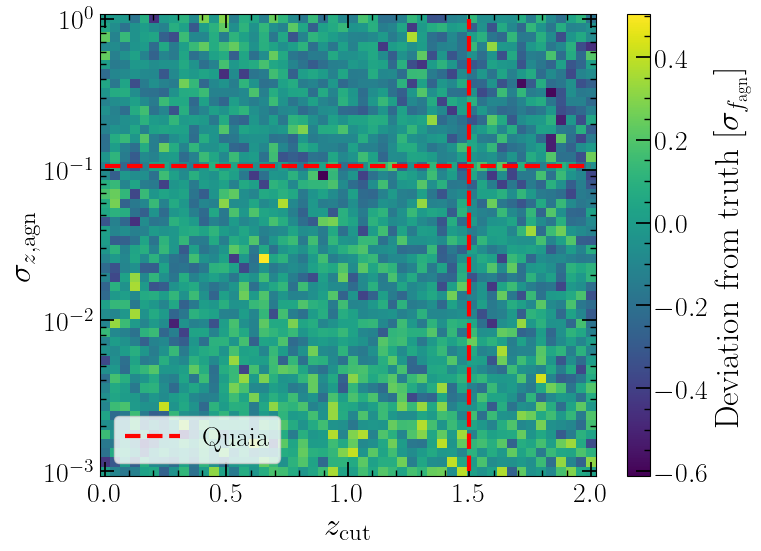

In [23]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/agn_zcut_vs_zerr_445_fagnrandom.json", 
                                                     param_values_dict,
                                                     verbose=False)

X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

fig, ax = plt.subplots(figsize=(8,6))  #plt.figure(figsize=(8,6))
pcm = ax.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', rasterized=True)  # , vmin=0.058, vmax=0.116
ax.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
ax.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
ax.set_xlabel(r"$z_{\rm cut}$")
ax.set_ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"$\sigma_{f_{\rm agn}}$")
# cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
ax.set_yscale('log')
ax.legend(loc='lower left')
upperax = ax.twiny()
cdfticks = np.array([0, 0.5, 1, 1.5, 2])
upperax.set_xticks(cdfticks)
upperax.set_xticklabels(np.around(agncdf_44p5_interp(cdfticks), 3))
upperax.set_xlabel('AGN CDF')
ax.set_xlim(X.min(), X.max())
upperax.set_xlim(X.min(), X.max())
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.yscale('log')
plt.legend(loc='lower left')
# plt.savefig('./p26plots/constraint_catalog_quality.pdf')
plt.show()


In [24]:
# mean_deviation_test = np.mean(mean_deviation_all, axis=2)

# plt.figure(figsize=(8,6))
# pcm = plt.pcolormesh(X, Y, mean_deviation_test, shading='auto', cmap='viridis', rasterized=True)
# plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
# plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
# plt.xlabel(r"$z_{\rm cut}$")
# plt.ylabel(r"$\sigma_{z, \rm agn}$")
# cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
# plt.yscale('log')
# plt.legend(loc='lower left')
# # plt.savefig('./p26plots/constraint_catalog_quality.pdf')
# plt.show()


### The biased case: neglecting redshift errors

/tmp/ipykernel_74397/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


0.10620452251911165
0.1206792640639329 1.510204081632653
0.10481131341546852 1.4693877551020407
-6.103069443102768


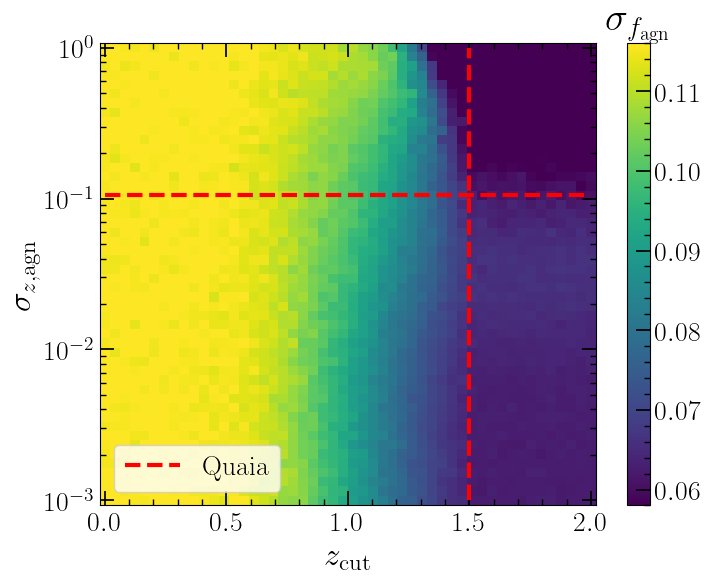

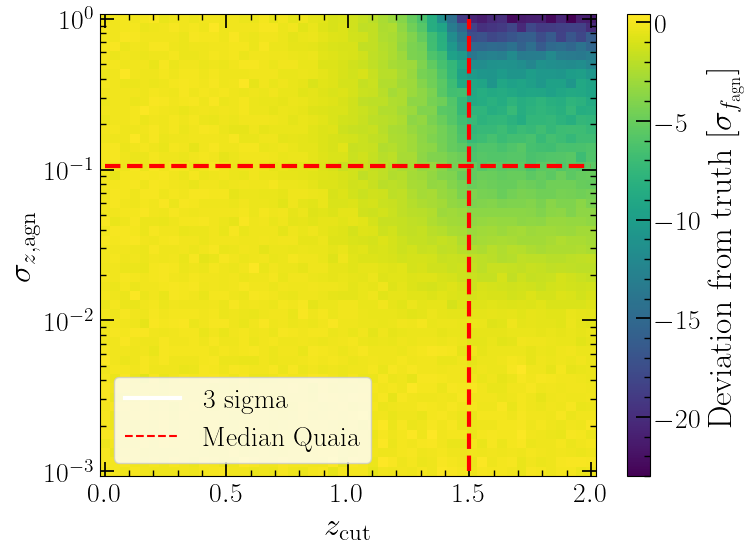

In [25]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/agn_zcut_vs_zerr_biased.json", param_values_dict)

zcut_quaia = 1.5
print(mean_err_quaia)

i = np.searchsorted(agn_zerrs, mean_err_quaia)
j = np.searchsorted(agn_zcuts, zcut_quaia)
print(agn_zerrs[i], agn_zcuts[j])
print(agn_zerrs[i-1], agn_zcuts[j-1])
print(mean_deviation[i, j])


X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', vmin=0.058, vmax=0.116, rasterized=True)
plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(zcut_quaia, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm)
cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
plt.yscale('log')
plt.legend(loc='lower left')
# plt.savefig('./p26plots/constraint_catalog_quality_biased.pdf')
plt.show()

plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
cs = plt.contour(X, Y, mean_deviation, levels=[3], colors='white', linewidths=3)
contour_proxy = mlines.Line2D([], [], color='white', linewidth=3,
                             label=r"3 sigma")
plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.yscale('log')
plt.legend(loc='lower left', 
           handles=[contour_proxy,
                    mlines.Line2D([], [], color='red', linestyle='dashed',
                                label='Median Quaia')])
# plt.savefig('./p26plots/constraint_catalog_quality_biased.pdf')
plt.show()



### Check bias from different completeness estimation methods. 
### Here: Complete up to z=1.5

/tmp/ipykernel_74397/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


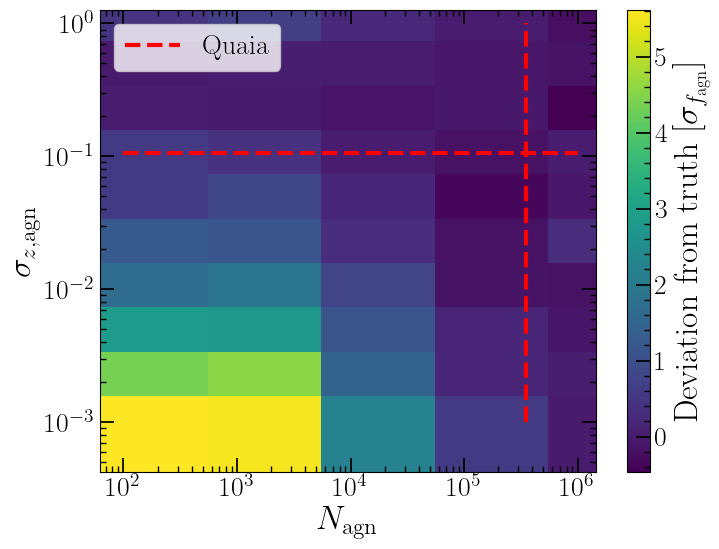

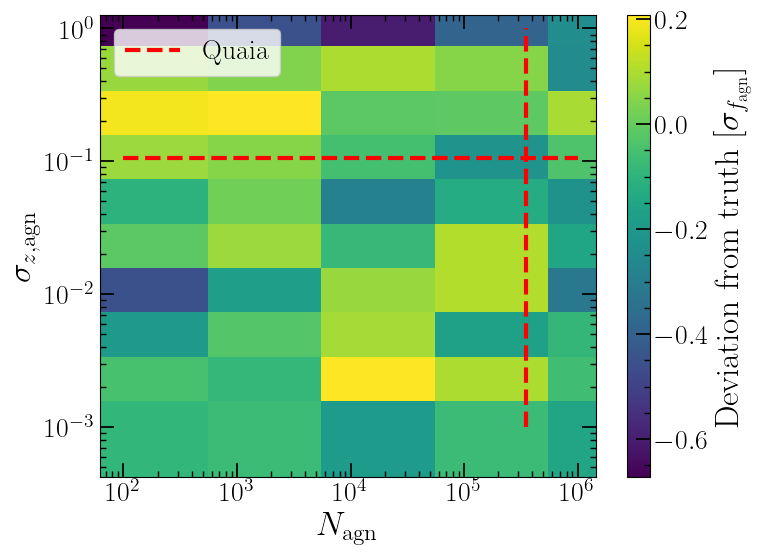

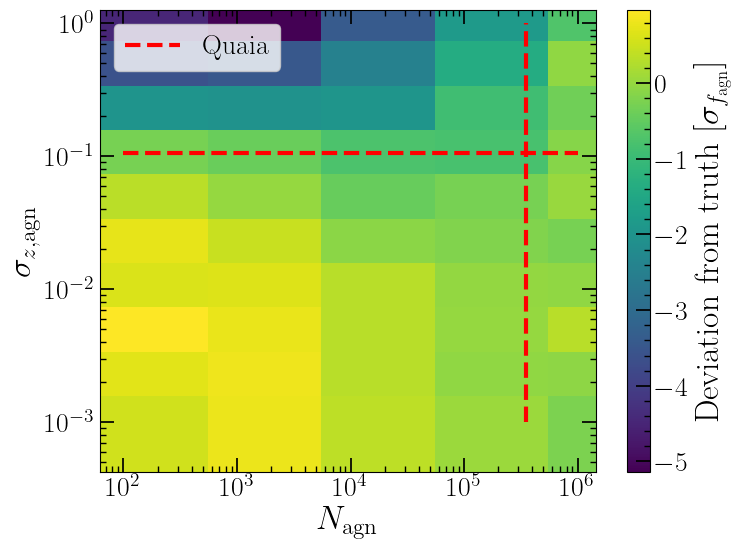

In [26]:
agn_zerrs = np.geomspace(0.001, 1, 10)
add_nagn = np.geomspace(100, 1000000, 5)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "ADD_NAGN_TO_CAT": add_nagn
}

X, Y = np.meshgrid(add_nagn, agn_zerrs)

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/fc_bias_p26.json", param_values_dict)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, add_nagn.min(), add_nagn.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(350000, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$N_{\rm agn}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.loglog()
plt.legend(loc='upper left')
plt.show()


sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/fc_bias_trueselfunc.json", param_values_dict)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, add_nagn.min(), add_nagn.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(350000, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$N_{\rm agn}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.loglog()
plt.legend(loc='upper left')
plt.show()


sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/fc_bias_v25.json", param_values_dict)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, add_nagn.min(), add_nagn.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(350000, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$N_{\rm agn}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.loglog()
plt.legend(loc='upper left')
plt.show()


### And now according to 44.5 redshift bins

/tmp/ipykernel_74397/2190795970.py:9: RuntimeWarning: invalid value encountered in subtract
  posteriors -= np.max(posteriors, axis=0)


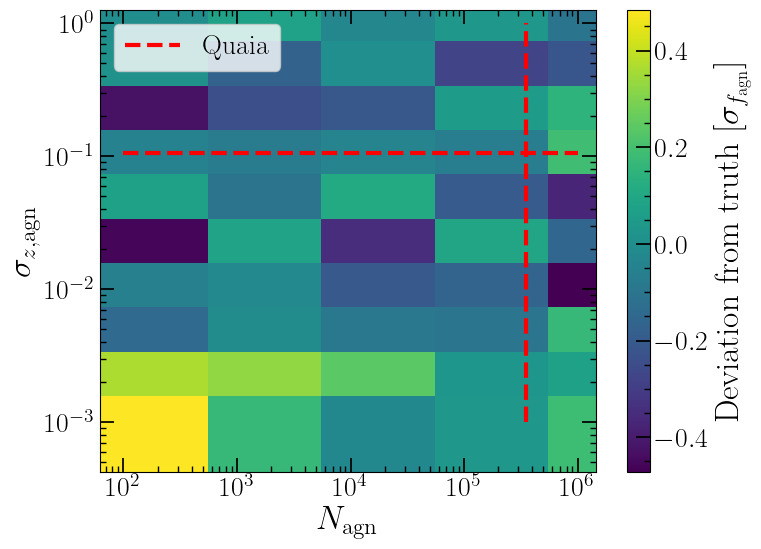

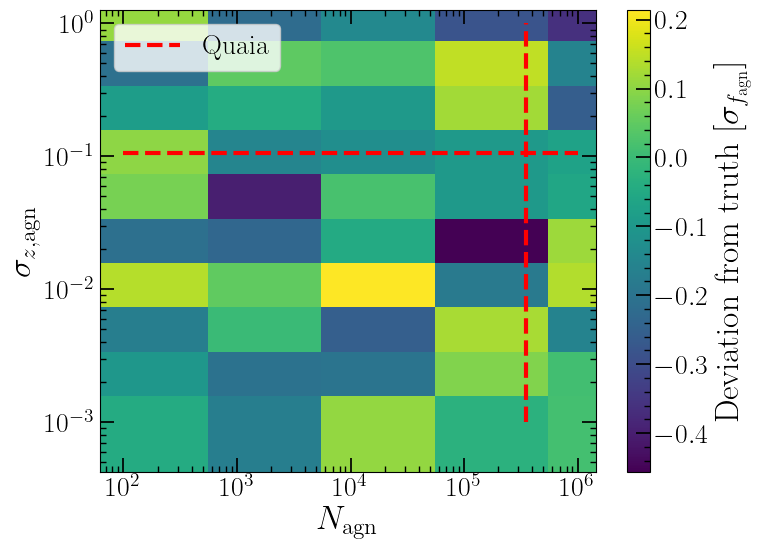

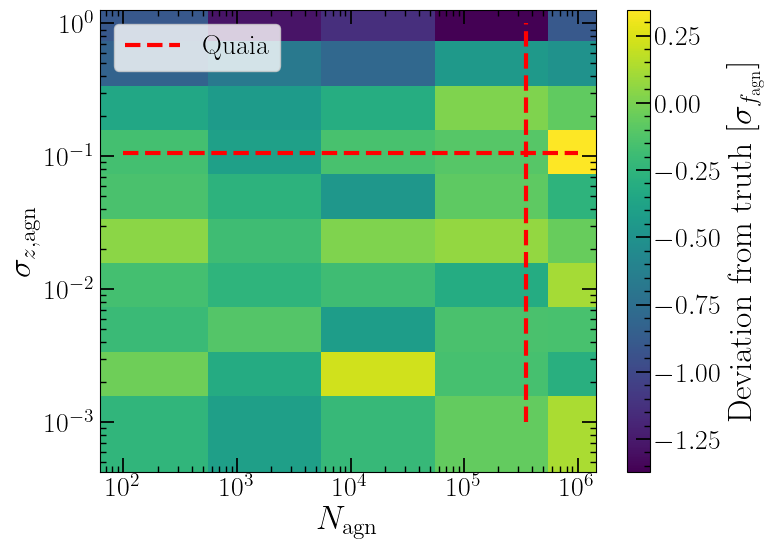

In [27]:
agn_zerrs = np.geomspace(0.001, 1, 10)
add_nagn = np.geomspace(100, 1000000, 5)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "ADD_NAGN_TO_CAT": add_nagn
}

X, Y = np.meshgrid(add_nagn, agn_zerrs)

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/fc_bias_p26_445.json", param_values_dict)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, add_nagn.min(), add_nagn.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(350000, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$N_{\rm agn}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.loglog()
plt.legend(loc='upper left')
plt.show()


sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/fc_bias_trueselfunc_445.json", param_values_dict)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, add_nagn.min(), add_nagn.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(350000, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$N_{\rm agn}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.loglog()
plt.legend(loc='upper left')
plt.show()


sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/fc_bias_v25_445.json", param_values_dict)
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
plt.hlines(mean_err_quaia, add_nagn.min(), add_nagn.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(350000, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$N_{\rm agn}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
plt.loglog()
plt.legend(loc='upper left')
plt.show()


In [28]:
# High-res unbiased

# agn_zerrs = np.geomspace(0.01, 1, 50)
# agn_zcuts = np.linspace(0, 2, 50)

# param_values_dict = {
#     "AGN_ZERROR": agn_zerrs,
#     "AGN_ZCUT": agn_zcuts
# }

# sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/agn_zcut_vs_zerr3.json", param_values_dict)
# # sig_fagn = np.around(sig_fagn, decimals=3)

# X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

# plt.figure(figsize=(8,6))
# pcm = plt.pcolormesh(X, Y, sig_fagn, shading='auto', cmap='viridis', vmin=0.06, vmax=0.116, rasterized=True)
# cs = plt.contour(X, Y, sig_fagn, levels=[0.116], colors='white', linewidths=3)
# contour_proxy = mlines.Line2D([], [], color='white', linewidth=3,
#                              label=r"No EM catalogue")

# plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Median Quaia')
# # plt.xlim(agn_zcuts.min(), agn_zcuts.max())
# # plt.ylim(agn_zerrs.min(), agn_zerrs.max())
# plt.xlabel(r"$z_{\rm cut}$")
# plt.ylabel(r"$\sigma_{z, \rm agn}$")
# cbar = plt.colorbar(pcm)
# cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
# plt.yscale('log')
# plt.legend(handles=[
#     contour_proxy,
#     mlines.Line2D([], [], color='red', linestyle='dashed',
#                   label='Median Quaia')
# ])
# plt.show()


# Now using the new mock data: larger V90 and including selection effects

In [29]:
def get_avg_alpha_coeffs(mockdata_root, start=0, stop=1000, Ntot=int(1e5)):

    avg_alpha_A = []
    avg_alpha_B = []

    Ngw_A_tot = 0
    Ngw_B_tot = 0

    Na = 0
    Nb = 0
    for i in np.arange(200)[start:stop]:

        g = glob.glob(f'{mockdata_root}/output_run_{i+1}_*')
        
        if len(g) == 0:
            Ngw_A = len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/agn/*'))
            Ngw_B = len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/alt/*'))
            ftemp = 0.5
        
        else:
            Ngw_A = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/agn/*'))
            Ngw_B = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/alt/*'))
            ftemp = float(g[0].split('_')[-1])

        Ngw_A_tot += Ngw_A
        Ngw_B_tot += Ngw_B
        Na += ftemp * Ntot
        Nb += (1 - ftemp) * Ntot

        avg_alpha_A.append(Ngw_A / (ftemp * Ntot))
        avg_alpha_B.append(Ngw_B / ((1 - ftemp) * Ntot))

    print('from Ngw', Ngw_A_tot / Na, Ngw_B_tot / Nb)
    print('from alpha', np.mean(np.array(avg_alpha_A)), np.mean(np.array(avg_alpha_B)))
    print('median from alpha', np.median(np.array(avg_alpha_A)), np.median(np.array(avg_alpha_B)))

    return np.mean(np.array(avg_alpha_A)), np.mean(np.array(avg_alpha_B))

print(get_avg_alpha_coeffs('/home/lucas/Documents/PhD/mock_gws_nonuniform_True_zmax_10_zcut_1_LVKvols', Ntot=int(3e3)))
print(get_avg_alpha_coeffs('/home/lucas/Documents/PhD/mock_gws_agndist_46.5_ngw_100000_zmax_10_zcut_0.3_LVKvols'))


# remove = []
# for i in range(200):
#     Ngw = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/agn/*'))
#     if Ngw == 0:
#         remove.append(i)
#         print(i)

# mask = np.zeros(200, dtype=bool)
# mask[remove] = True
def filter_posteriors(posteriors, start, stop):
    posteriors = posteriors[:, np.isfinite(posteriors).all(axis=0)]
    posteriors = posteriors[:, start:stop]
    posteriors_shape = posteriors.shape
    return posteriors, posteriors_shape


def correct_posteriors(posterior, posteriors_shape, mockdata_root, log_alpha):
    corrected_posteriors = np.zeros(posteriors_shape)
    Ngw_arr = []
    for k, (i, post) in enumerate( zip(np.arange(200)[start:stop], posterior.T) ):

        g = glob.glob(f'{mockdata_root}/output_run_{i+1}_*')
        if len(g) == 0:
            Ngw = len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/agn/*')) + len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/alt/*'))
        else:
            Ngw = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/agn/*')) + len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/alt/*'))
        
        corrected_log_llh = post - Ngw * log_alpha
        corrected_posteriors[:, k] = corrected_log_llh
        Ngw_arr.append(Ngw)
    return corrected_posteriors, Ngw_arr


def get_inverse_cdf_evals(nx, posterior, true_fagns):
    cdfs = get_cdfs(posterior)

    cdf_at_true_val = np.zeros(nx)
    q005 = np.zeros(nx)
    q050 = np.zeros(nx)
    q095 = np.zeros(nx)
    q016 = np.zeros(nx)
    q084 = np.zeros(nx)
    for i, cdf in enumerate(cdfs.T):
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q005[i] = inverse_cdf(0.05)
        q050[i] = inverse_cdf(0.50)
        q095[i] = inverse_cdf(0.95)
        q016[i] = inverse_cdf(0.16)
        q084[i] = inverse_cdf(0.84)

        cdf_at_true_val[i] = interp1d(LOG_LLH_X_AX, cdf)(true_fagns[i])
    return cdf_at_true_val, q005, q016, q050, q084, q095


from Ngw 0.01439 0.09877333333333334
from alpha 0.01439 0.09877333333333334
median from alpha 0.014666666666666666 0.09866666666666667
(np.float64(0.01439), np.float64(0.09877333333333334))
from Ngw 4.054217195741797e-05 0.0030445813528969935
from alpha 3.810575704866497e-05 0.003033229772457515
median from alpha 3.299076261025372e-05 0.0030400874580030586
(np.float64(3.810575704866497e-05), np.float64(0.003033229772457515))


In [30]:
# MC estimate of alpha

# agn_efficiency, alt_efficiency = 4.39e-05, 0.003033  # 46.5, z=0.3
# agn_efficiency, alt_efficiency = 0.0143458, 0.0990136  # 46.5, z=1

# agn_efficiency, alt_efficiency = 0.001407431397715323, 0.003029223806417793  # 44.5, z=0.3
# agn_efficiency, alt_efficiency = 0.08676494696142759, 0.09875389657421599  # 44.5, z=1

# Analytical estimate of alpha
# agn_efficiency, alt_efficiency = 4.158609789980338e-05, 0.0029181111806662182  # 46.5, z=0.3
# agn_efficiency, alt_efficiency = 0.013998555438527785, 0.09782308039965569  # 46.5, z=1

# agn_efficiency, alt_efficiency = 0.0014369976475854384, 0.0029180323456043876  # 44.5, z=0.3
# agn_efficiency, alt_efficiency = 0.08591413903042647, 0.09786327907001525  # 44.5, z=1


In [31]:
# '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T15:48:57.887421.npz'  # 44.5, z=0.3, no catalogue

from Ngw 0.014577287912038004 0.09919522844838284
from alpha 0.01484808413480772 0.09918753934045679
median from alpha 0.014266059703855066 0.09919632940991346
Mean realized coeffs: (np.float64(0.01484808413480772), np.float64(0.09918753934045679))
1 1
Median 90% CI size = 0.5034127217164293
Median 1 sigma = 0.15977688097110626
Mean 1 sigma = 0.15065003823530057



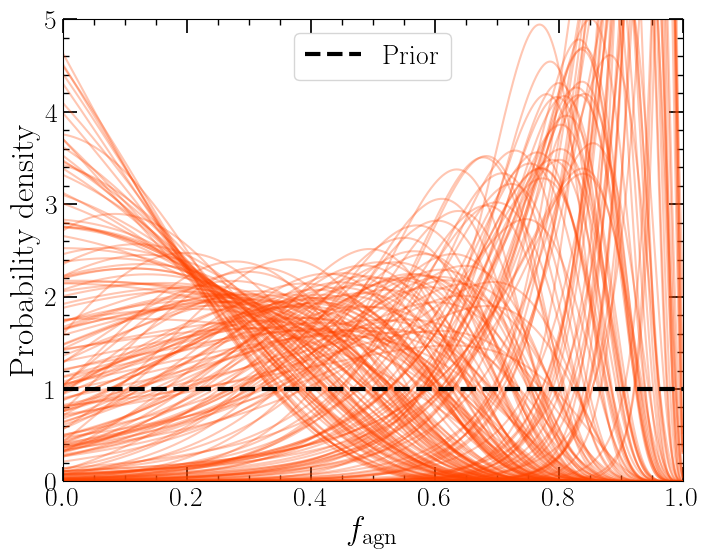

5sigma off: []


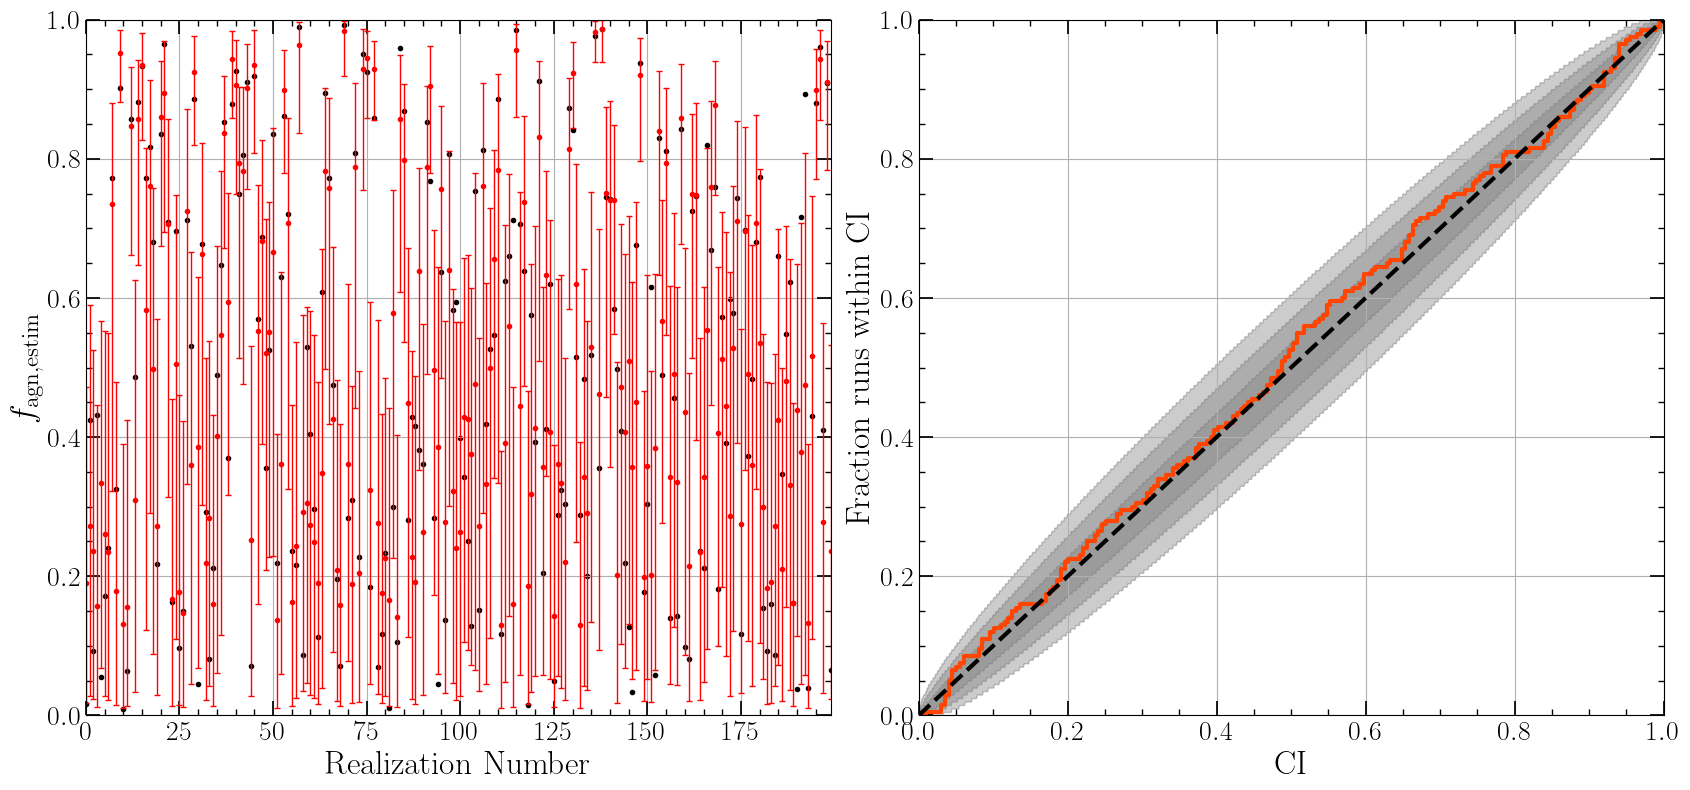

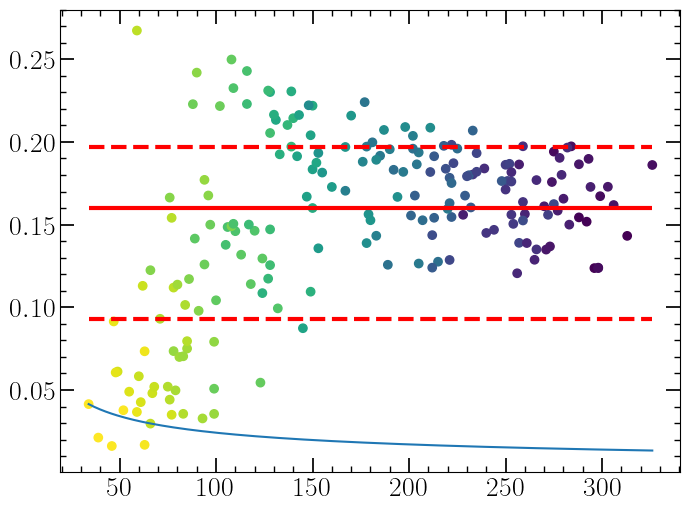

In [38]:
PLOT_OR_ERRORBAR = 'errorbar'
# mockdata_root =  '/home/lucas/Documents/PhD/mock_gws_agndist_46.5_ngw_100000_zmax_10_zcut_0.3_LVKvols'
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-18T16:52:18.762144.npz' #'/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-13T15:04:57.761095.npz'

mockdata_root =  '/home/lucas/Documents/PhD/mock_gws_agndist_46.5_ngw_3000_zmax_10_zcut_1.0_LVKvols'
posterior_path = '../fagn_posteriors/p26_post_realdata_False_2026-05-19T16:57:00.808535.npz'



# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-04-08T10:43:07.970697.npy'
# posterior_path = "/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-01T14:00:42.656411.npz"  #'/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-04T18:49:42.911949.npz'  #"/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-01T14:00:42.656411.npz"
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T11:18:36.700474.npz'
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T14:53:16.425107.npz'

# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T15:52:49.253847.npz'  # 46.5, z=0.3, no catalogue
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T16:37:03.319258.npz'  # 46.5, z=0.3, perfect catalogue

# mockdata_root = '/home/lucas/Documents/PhD/mock_gws_agndist_44.5_ngw_100000_zmax_10_zcut_0.3_LVKvols'
# posterior_path =  '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T11:35:54.546958.npz'  # '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T11:38:00.200249.npz'  #
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T13:48:36.464504.npz'#'/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T13:33:33.533349.npz' #'/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T13:29:05.588953.npz'  # 44.5 lumthresh
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T14:56:33.875686.npz'
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T15:48:57.887421.npz'
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T16:44:18.165261.npz'  # 44.5, z=0.3, only GW-generating AGN

# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-07T11:37:13.180309.npz'  # 44.5, z=0.3, agncut = 0.3, agnerr = 0.1, nagn = 0 --> only bias from few 5 sig downward biased realizations
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-07T11:42:46.088956.npz'  # 44.5, z=0.3, agncut = 0.3, agnerr = 0.1, nagn = 1e5 --> strong downward bias accross realizations

# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T14:15:47.512366.npz'
# posterior_path = '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T15:24:40.445515.npz'

start = 0
stop = 200

Ntot = int(3e3)
fagn_true = None
print('Mean realized coeffs:', get_avg_alpha_coeffs(mockdata_root, start=start, stop=stop, Ntot=Ntot))

agn_efficiency, alt_efficiency = 1,1  #get_avg_alpha_coeffs(mockdata_root, start=start, stop=stop, Ntot=Ntot)  # 1,1 #
log_alpha = np.log(agn_efficiency * LOG_LLH_X_AX + (1 - LOG_LLH_X_AX) * alt_efficiency)
print(agn_efficiency, alt_efficiency)

posterior, posteriors_shape, true_fagns = load_log_llh(posterior_path, fagn_true=fagn_true)
true_fagns = true_fagns[start:stop]
posterior, posteriors_shape = filter_posteriors(posterior, start, stop)
posterior, Ngw_arr = correct_posteriors(posterior, posteriors_shape, mockdata_root, log_alpha)

# remove = [ 28,  36,  40,  53,  59,  63,  69,  79,  81,  92, 106, 109, 120, 123, 139, 146, 148, 155,
#  162, 164, 165, 177, 180, 184, 193]
# mask = np.ones(200, dtype=bool)
# mask[remove] = False
# posterior = posterior[:,mask]
# posteriors_shape = posterior.shape
# true_fagns = true_fagns[mask]

pdfs = get_pdfs(posterior, LOG_LLH_X_AX)

cdf_at_true_val, q005, q016, q050, q084, q095 = get_inverse_cdf_evals(posteriors_shape[1], posterior, true_fagns)
print(f'Median 90% CI size = {np.median(q095[~np.isnan(q095)] - q005[~np.isnan(q095)])}')
print(f'Median 1 sigma = {np.median( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}')
print(f'Mean 1 sigma = {np.mean( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}\n')

sig = (q084 - q016)/2


########## Plotting ##########

idx = 0

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[0], alpha=0.3)
ax.hlines(1, 0, 1, linestyles='dashed', colors='black', linewidth=3, label='Prior')
ax.set_xlabel(r'$f_{\rm agn}$')
ax.set_ylabel(r'Probability density')
ax.set_xlim(0, 1)
ax.set_ylim(0, min(1.1 * np.max(pdfs), 5))
ax.legend()
plt.show()

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,8))
xx = np.arange(posteriors_shape[1])
# Posteriors
if PLOT_OR_ERRORBAR == 'plot':
    ax1.plot(xx, q050, color='orangered', linewidth=3, label='Median')
    ax1.fill_between(xx, q005, q095, color='orangered', alpha=0.3, label=r'90$\%$ CI')
elif PLOT_OR_ERRORBAR == 'errorbar':
    ax1.errorbar(x=xx, 
                y=q050,
                yerr=np.array([q050 - q005, q095 - q050]),
                linestyle='',
                marker='.',
                color='red',
                capsize=2,
                elinewidth=1)
    ax1.errorbar(x=xx[abs(q050 - true_fagns)/(q084 - q016) > 5], 
                y=q050[abs(q050 - true_fagns)/(q084 - q016) > 5],
                linestyle='',
                marker='.',
                color='blue',
                capsize=2,
                elinewidth=1)
    print('5sigma off:', xx[abs(q050 - true_fagns)/(q084 - q016) > 5])
ax1.scatter(xx, true_fagns, color='black', marker='.')
ax1.set_xlabel(r'Realization Number')
ax1.set_ylabel(r'$f_{\rm agn, estim}$')
ax1.grid()
ax1.set_xlim(0, posteriors_shape[1] - 1)
ax1.set_ylim(0, 1)

# PP plot
Nrep = len(cdf_at_true_val)
comparisons = np.linspace(0, 1, Nrep)
pp_plot = np.zeros(Nrep)
for i in range(len(pp_plot)):
    pp_plot[i] = np.sum(cdf_at_true_val <= comparisons[i])
pp_plot /= len(cdf_at_true_val)

ax2.step(comparisons, pp_plot, linewidth=3, color=COLORS[idx])

CI = np.linspace(0, 0.9999, 1000)
for ci, alpha in zip([0.6827, 0.9545, 0.9973], [0.1,0.15,0.2]):
    edge_of_bound = (1. - ci) / 2.
    lower = binom.ppf(1 - edge_of_bound, Nrep, CI) / Nrep
    upper = binom.ppf(edge_of_bound, Nrep, CI) / Nrep
    lower[0] = 0
    upper[0] = 0
    plt.fill_between(CI, lower, upper, alpha=alpha, color='k')

ax2.plot(np.linspace(0,1,100), np.linspace(0,1,100), linestyle='dashed', color='black', zorder=6, linewidth=3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid()
# ax2.set_title(str(Nrep) + ' realizations of ' + r'$f_{\rm agn, true} =$ ' + str(fagn_true))
ax2.set_xlabel('CI')
ax2.set_ylabel('Fraction runs within CI')
plt.tight_layout()
# if save:
#     plt.savefig(f'./p26plots/{save}.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
s016, s084, s050 = np.quantile(sig, 0.16), np.quantile(sig, 0.84), np.quantile(sig, 0.5)
ax.hlines(s050, np.min(Ngw_arr), np.max(Ngw_arr), linestyles='solid', colors='red', linewidth=3, label='Median sigma')
ax.hlines(s084, np.min(Ngw_arr), np.max(Ngw_arr), linestyles='dashed', colors='red', linewidth=3)
ax.hlines(s016, np.min(Ngw_arr), np.max(Ngw_arr), linestyles='dashed', colors='red', linewidth=3)
ax.scatter(Ngw_arr, sig, c=true_fagns)
NN = np.linspace(np.min(Ngw_arr), np.max(Ngw_arr), len(Ngw_arr))
ax.plot(NN, sig[np.argmin(Ngw_arr)] / np.sqrt(NN / np.min(Ngw_arr)))
plt.show()
